Name: Fahmi Sajid Ahmed / Huzaifa Nissare-Houssen<br>
Student Number: 300250180 / 300172186<br>

<h3><b>Work Split</h3>
<p>
    The assignment was split into 2 distinct parts (Regression Empirical Study with Linear Regression and Classification Empirical Study with Decision Trees). The entire thing was done solely by Fahmi Sajid Ahmed (300250180).
</p>

<h3>Dataset Description</h3>
<p>
    The Vehicle dataset (compiled by Nehal Birla, Nishant Verma, Nikhil Kushwaha) was created for a variety of purposes (i.e. exemplifying the use of linear regression in machine learning). In the case of this assignment, it will be used to perform an empirical study in which we evaluate a linear regression approach on a regression task.
</p>
<p>
    We plan on using the "car details v3.csv" file for the regression analysis. This dataset consists of <b>13 attributes</b> and <b>something rows</b>.
</p>
<p>
    The attributes are as follows:
    <ul>
        <li>name: A categorical attribute defining the name of the vehicle (model)</li>
        <li>year: A numerical attribute defining the year that the car was bought</li>
        <li>selling_price: A numerical attribute defining the selling price of the car (assuming in USD)</li>
        <li>km_driven: A numerical attrribute denoting the number of kilometers that the car was driven</li>
        <li>fuel: A categorical attribute denoting the type of fuel the car uses</li>
        <li>seller_type: A categorical attribute describing if the car was sold by an individual or a dealership</li>
        <li>transmission: A categorical attribute describing if the car is a manual or an automatic</li>
        <li>owner: A categorical attribute denoting the numnber of previous owners the vehicle has had</li>
        <li>mileage: A numerical attribute denoting the mileage of the car</li>
        <li>engine: A numerical attribute describing the engine capacity of the car (in CCs)</li>
        <li>max_power: A numerical attribute denoting the max power of the engine (in bhp)</li>
        <li>torque: A numerical(?) attribute denoting the torque of the car (kgm @ rpm)</li>
        <li>seats: A numerical variable denoting the number of seats in the car</li>
    </ul>
</p>

In [2]:
# Data Cleaning and Imputation
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt;
import seaborn as sns;
import re;
import warnings;
warnings.filterwarnings("ignore");

# Display options for panda
pd.set_option("display.max_columns", None);
pd.set_option("display.float_format", "{:.2f}".format);

# Load the dataset
df = pd.read_csv("https://raw.githubusercontent.com/Fahmi-IT/CSI4142_A3/refs/heads/part1/Car%20details%20v3.csv");

# Overview of data
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isnull().sum(),
    "miss_%": (df.isnull().mean() * 100).round(2),
    "unique": df.nunique(),
    "sample": [df[c].dropna().iloc[0] if df[c].notna().any() else "—" for c in df.columns],
});
print(summary.to_string());

# Check 1: Duplicates
n_dupes = df.duplicated().sum();
print("\nSample duplicated entries:");
print(df[df.duplicated(keep=False)].sort_values("name").head(6));
df.drop_duplicates(inplace=True);
df.reset_index(drop=True, inplace=True);
print(f"\nAfter deduplication: {df.shape[0]:,} rows remain.");

# Check 2: Year Validity
current_year = 2026;
invalid_year = df[(df["year"] < 1885) | (df["year"] > current_year)];
print(f"Rows with year outside [1885, {current_year}]: {len(invalid_year)}");
if not invalid_year.empty:
    print(invalid_year[["name", "year"]].drop_duplicates());

# Check 3: Negative / Zero prices + km_driven
km_thresh = 1_000_000; # extreme threshold
df["km_driven_flag"] = df["km_driven"] > km_thresh;
print(f"\nRows flagged (km_driven > {km_thresh:,}):");
print(df[df["km_driven_flag"]][["name", "year", "km_driven"]]);

# Check 4: Categorical Column Validity
cats = {
    "fuel": ["Petrol", "Diesel", "CNG", "LPG"],
    "seller_type": ["Individual", "Dealer", "Trustmark Dealer"],
    "transmission": ["Manual", "Automatic"],
    "owner": ["First Owner", "Second Owner", "Third Owner",
                     "Fourth & Above Owner", "Test Drive Car"],
};
for col, valid in cats.items():
    bad = df[~df[col].isin(valid)][col].unique();
    flag = "Error" if len(bad) > 0 else "Success";
    print(f"{flag} '{col}' - unexpected values: {bad if len(bad) else 'none'}");

# Check 5: seats Validity
suspect_seats = df[df["seats"] > 10]; # More than 10 seats is implausible
print(f"\nRows with seats > 10: {len(suspect_seats)}");
if not suspect_seats.empty:
    print(suspect_seats[["name", "seats"]]);
df.loc[df["seats"] > 10, "seats"] = np.nan; # Replace excess seat values with NaN for imputation

# Some data is represented as a messy string, so the following code section is dedicated to parsing that data into a digestible format
# Parse 1: Mileage (kmpl / km/kg => float)
def parse_mileage(val):
    """Return (numeric_value, unit) or (NaN, None)."""
    if pd.isna(val):
        return np.nan, None;
    m = re.match(r"([\d.]+)\s*(kmpl|km/kg)", str(val).strip(), re.IGNORECASE);
    if m:
        return float(m.group(1)), m.group(2).lower();
    return np.nan, None;

df[["mileage_val", "mileage_unit"]] = pd.DataFrame(
    df["mileage"].apply(lambda x: parse_mileage(x)).tolist(), # Apply lambda function to parse mileage function to each
    index=df.index,
);

print(f"Unit counts:\n{df['mileage_unit'].value_counts(dropna=False).to_string()}");
print(f"Unparseable rows: {df['mileage_val'].isna().sum()}");
print(f"mileage_val describe:\n{df['mileage_val'].describe().to_string()}");

# Parse 2: Engine (CC => int)
def parse_engine(val):
    if pd.isna(val):
        return np.nan;
    m = re.match(r"([\d.]+)\s*CC", str(val).strip(), re.IGNORECASE);
    return float(m.group(1)) if m else np.nan;

df["engine_cc"] = df["engine"].apply(parse_engine);
print(f"Unparseable: {df['engine_cc'].isna().sum()}");
print(df["engine_cc"].describe().to_string());

# Parse 3: max power (bhp => float)
def parse_power(val):
    if pd.isna(val):
        return np.nan;
    # Edge-case: some entries are just "bhp" with no associated scalar value
    m = re.match(r"([\d.]+)\s*bhp", str(val).strip(), re.IGNORECASE);
    return float(m.group(1)) if m else np.nan;

df["max_power_bhp"] = df["max_power"].apply(parse_power);
print(f"Unparseable: {df['max_power_bhp'].isna().sum()}");
print(df["max_power_bhp"].describe().to_string());

# Parse 4: torque (normalise to Nm)
KGM_TO_NM = 9.80665

def parse_torque(val):
    if pd.isna(val):
        return np.nan;
    s = str(val).strip().replace(",", "");
    # Pattern: leading number, optional unit
    m = re.match(r"([\d.]+)\s*(Nm|nm|kgm|KGM)?", s, re.IGNORECASE);
    if not m:
        return np.nan;
    value = float(m.group(1));
    unit  = (m.group(2) or "").lower();
    # If no explicit unit, infer from context
    if unit in ("kgm",):
        value *= KGM_TO_NM;
    elif unit == "" and "kgm" in s.lower():
        value *= KGM_TO_NM;
    return round(value, 2);

df["torque_nm"] = df["torque"].apply(parse_torque);
print(f"Unparseable: {df['torque_nm'].isna().sum()}");
print(df["torque_nm"].describe().to_string());

# Check 6: Numeric Range Checks on Parsed Values
checks = {
    "mileage_val (0–80)": (df["mileage_val"], 0, 80),
    "engine_cc (50–6000)":(df["engine_cc"], 50, 6000),
    "max_power_bhp (5–600)": (df["max_power_bhp"], 5, 600),
    "torque_nm (5–2000)": (df["torque_nm"], 5, 2000),
    "seats (2–10)": (df["seats"], 2, 10),
}
for label, (col, lo, hi) in checks.items():
    out = ((col < lo) | (col > hi)).sum();
    flag = "Error" if out else "Success";
    print(f"  {flag}  {label}: {out} out-of-range rows");

# Extreme Mileage Rows
print("\nRows with mileage_val > 50 kmpl (potential data entry errors):");
print(df[df["mileage_val"] > 50][["name", "year", "fuel", "mileage_val"]].head(10));

NUMERIC_COLS = [
    "year", "selling_price", "km_driven",
    "mileage_val", "engine_cc", "max_power_bhp", "torque_nm", "seats",
];

# Check 7: Co-occurrence of missing values
miss_mask = df[NUMERIC_COLS].isnull();
print(miss_mask.sum(axis=1).value_counts().sort_index()
      .rename("rows_with_N_missing_cols").to_string());

# Rows where ALL five parsed columns are missing
all_missing = miss_mask.all(axis=1);
print(f"\nRows missing ALL 5 parsed numeric cols: {all_missing.sum()}");
print(df[all_missing][["name", "year", "fuel", "selling_price"]].head());

# Helper Columns (for grouping)
df["make"] = df["name"].str.split().str[0];
df["year_bin"] = pd.cut(df["year"], bins=range(1980, 2026, 5),
                        labels=[f"{y}–{y+4}" for y in range(1980, 2021, 5)],
                        right=False);

# Imputation 1: Seats (Default Value Imputation (Mode))
def group_mode(series):
    """Return the mode of a series, or NaN if all missing."""
    m = series.dropna().mode();
    return m.iloc[0] if not m.empty else np.nan;

before = df["seats"].isna().sum();
df["seats"] = df.groupby(["make", "fuel"], observed=True)["seats"].transform(
    lambda s: s.fillna(group_mode(s))
);
# Fallback (global mode)
global_seats_mode = group_mode(df["seats"]);
df["seats"].fillna(global_seats_mode, inplace=True);
df["seats"] = df["seats"].astype("Int64");

print(f"[IMPUTE] seats: {before} NaN => {df['seats'].isna().sum()} NaN remaining");
print(f"Global mode used as fallback: {global_seats_mode}");

# Impute 2: mileage_val, engine_cc, max_power_bhp, torque_nm (Default Value Imputation (Median))
def fill_group_median(df, col, groups):
    before = df[col].isna().sum();
    df[col] = df.groupby(groups, observed=True)[col].transform(
        lambda s: s.fillna(s.median())
    );
    # Fallback (global median)
    global_med = df[col].median();
    df[col].fillna(global_med, inplace=True);
    after = df[col].isna().sum();
    print(f"[IMPUTE] {col:<16}: {before} NaN → {after} NaN  "
          f"(global median fallback = {global_med:.2f})")
    return df;

group_cols = ["fuel", "year_bin"];
for col in ["mileage_val", "engine_cc", "max_power_bhp", "torque_nm"]:
    df = fill_group_median(df, col, group_cols);

                 dtype  missing  miss_%  unique                  sample
name            object        0    0.00    2058  Maruti Swift Dzire VDI
year             int64        0    0.00      29                    2014
selling_price    int64        0    0.00     677                  450000
km_driven        int64        0    0.00     921                  145500
fuel            object        0    0.00       4                  Diesel
seller_type     object        0    0.00       3              Individual
transmission    object        0    0.00       2                  Manual
owner           object        0    0.00       5             First Owner
mileage         object      221    2.72     393               23.4 kmpl
engine          object      221    2.72     121                 1248 CC
max_power       object      215    2.65     322                  74 bhp
torque          object      222    2.73     441          190Nm@ 2000rpm
seats          float64      221    2.72       9                 

### a) Cleaning the Data

The cleaning pipeline reuses the validity-check and imputation methods developed in Assignment 2 and applies them to the car details dataset.

**Validity Checks**

1. **Duplicates** - The dataset is checked for fully duplicated rows and all duplicates are dropped, keeping only the first occurrence.
2. **Year validity** - Rows with a `year` outside the plausible range [1885, 2026] are flagged. No rows fell outside this range.
3. **Extreme km_driven** - Any car with `km_driven` above 1,000,000 is flagged with a boolean column (`km_driven_flag`). These rows are kept but marked for downstream review.
4. **Categorical validity** - The four categorical columns (`fuel`, `seller_type`, `transmission`, `owner`) are checked against their known valid sets. No unexpected values were found.
5. **Seats validity** - Entries with more than 10 seats are considered implausible for a standard passenger vehicle and are replaced with `NaN` (to be handled by imputation).

**Parsing**

Four columns are stored as mixed strings in the raw CSV and need to be parsed into usable floats before any modelling can take place:

- `mileage` => `mileage_val` (float) + `mileage_unit` (kmpl or km/kg). Extracts the numeric part and the unit separately.
- `engine` => `engine_cc` (float). The CC value is extracted.
- `max_power` => `max_power_bhp` (float). Edge cases where the string contains only the unit `"bhp"` with no number are handled and returned as `NaN`.
- `torque` => `torque_nm` (float, normalised to Nm). Values expressed in kgm are converted using the factor 1 kgm = 9.80665 Nm (referenced via Google).

After parsing (via regex), a range check confirms that all values fall within physically plausible bounds.

**Imputation**

Missing values are filled using grouped imputation strategies rather than a single global statistic, so that each car is filled with values typical of its own sub-group:

- `seats` => **Mode imputation**, grouped by `(make, fuel)`. The mode is the most meaningful fill for a discrete count like seat numbers. A global mode is used as a fallback when a group has no observed values.
- `mileage_val`, `engine_cc`, `max_power_bhp`, `torque_nm` => **Median imputation**, grouped by `(fuel, year_bin)`. The median is chosen over the mean because these numeric columns have right-skewed distributions; a global median is used as a fallback.

In [3]:
# Columns to one-hot encode
OHE_COLS = ["fuel", "seller_type", "transmission", "owner"];

# Columns intentionally excluded
EXCLUDED = {
    "name": "High cardinality (2 058 unique values) — OHE would create thousands of sparse columns",
    "make": "Derived helper column; redundant once 'name' is dropped",
    "mileage": "Raw string — superseded by parsed 'mileage_val' / 'mileage_unit'",
    "mileage_unit": "Unit label only; captured implicitly by mileage_val scale",
    "engine": "Raw string — superseded by parsed 'engine_cc'",
    "max_power": "Raw string — superseded by parsed 'max_power_bhp'",
    "torque": "Raw string — superseded by parsed 'torque_nm'",
    "year_bin": "Grouping helper used during imputation only",
    "km_driven_flag": "Boolean audit flag, not a model feature",
};

print("Columns excluded from the modelling DataFrame:");
for col, reason in EXCLUDED.items():
    print(f"  • {col:<16} — {reason}");

# drop_first=True drops one dummy per group to avoid perfect multicollinearity (dummy variable trap), which would make the design matrix singular.
df_encoded = pd.get_dummies(
    df[NUMERIC_COLS + OHE_COLS],
    columns=OHE_COLS,
    drop_first=True,
    dtype=int,  # Encode as 0/1 integers rather than booleans
);

# Identify which dummy was dropped per categorical column (the reference level)
ref_levels = {};
for col in OHE_COLS:
    all_vals = sorted(df[col].dropna().unique());
    ref_levels[col] = all_vals[0];  # pd.get_dummies drops the first sorted category

print("\nDropped reference levels (drop_first=True):");
for col, ref in ref_levels.items():
    print(f"- {col:<14} => '{ref}' dropped");

# New dummy columns that were added
original_cols = set(NUMERIC_COLS);
new_dummy_cols = [c for c in df_encoded.columns if c not in original_cols];
print(f"\nDummy columns created ({len(new_dummy_cols)} total):");
for c in new_dummy_cols:
    print(f"  • {c}");

print(f"\nFinal encoded DataFrame: {df_encoded.shape[0]:,} rows × {df_encoded.shape[1]} columns");
print(f"Numeric columns: {len(NUMERIC_COLS)}");
print(f"Dummy columns: {len(new_dummy_cols)}");
print(f"Missing values: {df_encoded.isnull().sum().sum()}");

print("\nSample of encoded DataFrame (first 3 rows):");
print(df_encoded.head(3).to_string());

Columns excluded from the modelling DataFrame:
  • name             — High cardinality (2 058 unique values) — OHE would create thousands of sparse columns
  • make             — Derived helper column; redundant once 'name' is dropped
  • mileage          — Raw string — superseded by parsed 'mileage_val' / 'mileage_unit'
  • mileage_unit     — Unit label only; captured implicitly by mileage_val scale
  • engine           — Raw string — superseded by parsed 'engine_cc'
  • max_power        — Raw string — superseded by parsed 'max_power_bhp'
  • torque           — Raw string — superseded by parsed 'torque_nm'
  • year_bin         — Grouping helper used during imputation only
  • km_driven_flag   — Boolean audit flag, not a model feature

Dropped reference levels (drop_first=True):
- fuel           => 'CNG' dropped
- seller_type    => 'Dealer' dropped
- transmission   => 'Automatic' dropped
- owner          => 'First Owner' dropped

Dummy columns created (10 total):
  • fuel_Diesel
  • fu

### b) Categorical Feature Encoding

Linear regression requires all inputs to be numeric. The four categorical columns (`fuel`, `seller_type`, `transmission`, and `owner`) are converted using **one-hot encoding (OHE)** via `pd.get_dummies()`.

**`drop_first=True`**: One dummy column is dropped per categorical variable to avoid perfect multicollinearity (the "dummy variable trap"). Without this, the dummy columns for any one variable sum to a constant, making the design matrix singular and the OLS solution undefined.

**Columns excluded from the model**

Not all columns in `df` are carried forward into the design matrix. The following are intentionally excluded:

- `name` and `make`: `name` has 2,058 unique values; one-hot encoding it would produce thousands of near-empty columns and cause severe overfitting. `make` is a derived helper and is redundant once `name` is dropped.
- `mileage`, `engine`, `max_power`, `torque`: These are the raw string columns already replaced by their parsed numeric equivalents.
- `mileage_unit`: Unit label only; the scale difference between kmpl and km/kg is already captured by the numeric value.
- `year_bin`: A helper column created solely for grouped imputation; it adds no additional information beyond `year`.
- `km_driven_flag`: A boolean audit flag from the cleaning step, not a model feature.

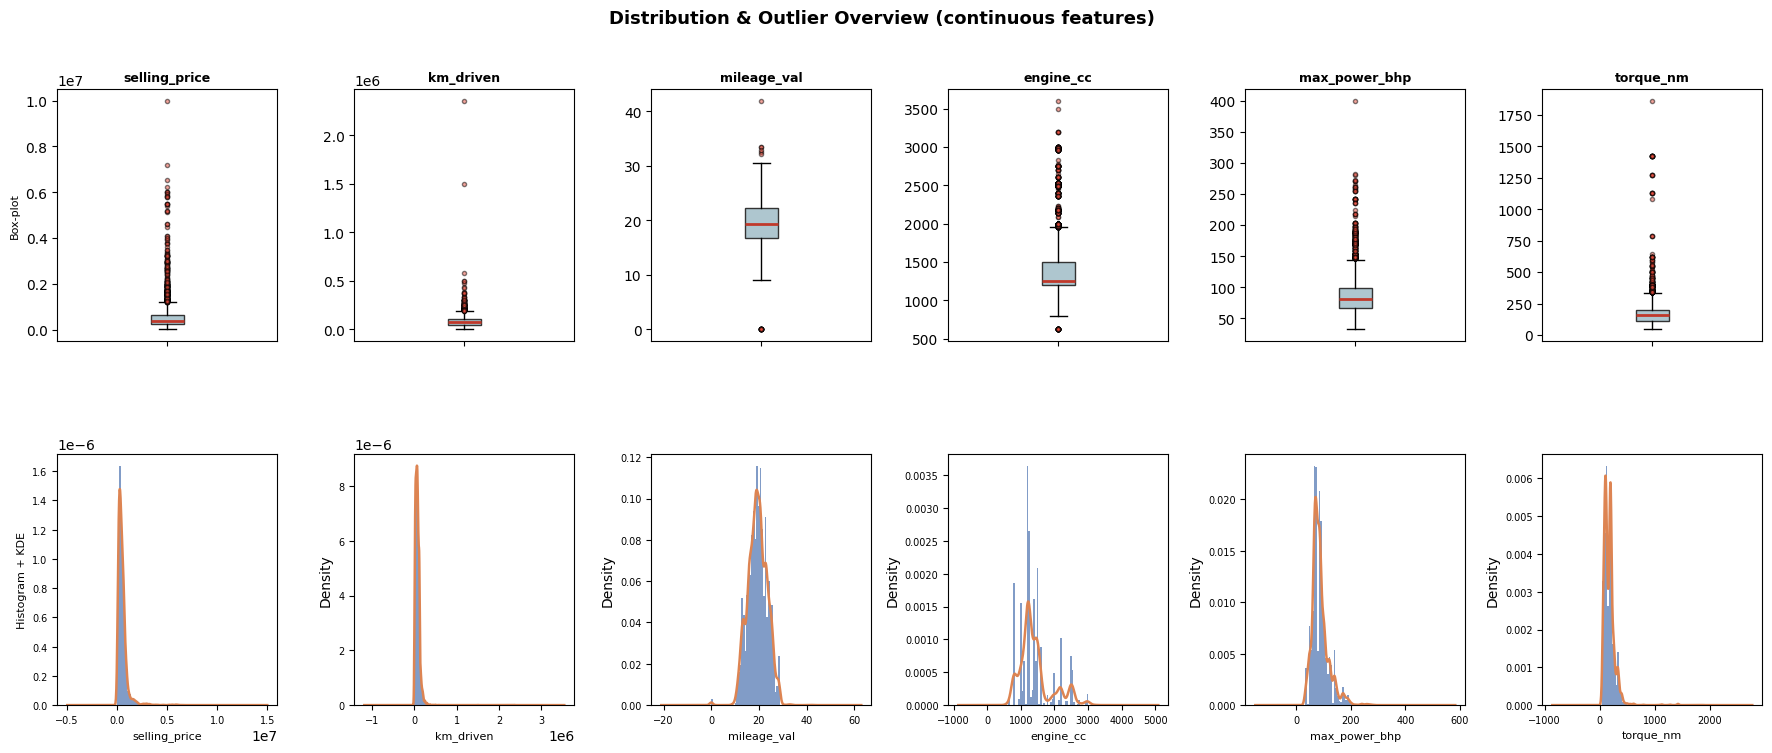

Feature                      Q1         Q3        IQR        Lower        Upper   # Outliers  % Outliers
----------------------------------------------------------------------------------------------------
selling_price         250000.00  633500.00  383500.00   -325250.00   1208750.00          328        4.7%
km_driven              40000.00  100000.00   60000.00    -50000.00    190000.00          167        2.4%
mileage_val               16.80      22.32       5.52         8.52        30.60           21        0.3%
engine_cc               1196.00    1498.00     302.00       743.00      1951.00         1213       17.5%
max_power_bhp             67.10      99.00      31.90        19.25       146.85          371        5.4%
torque_nm                110.00     200.06      90.06       -25.09       335.15          306        4.4%


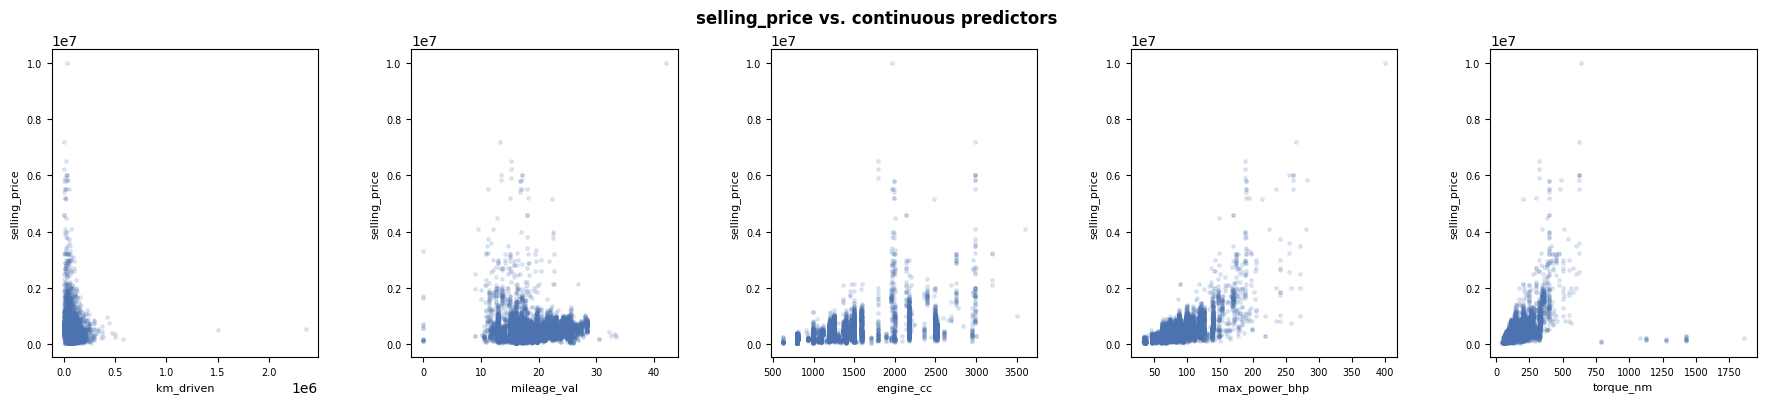

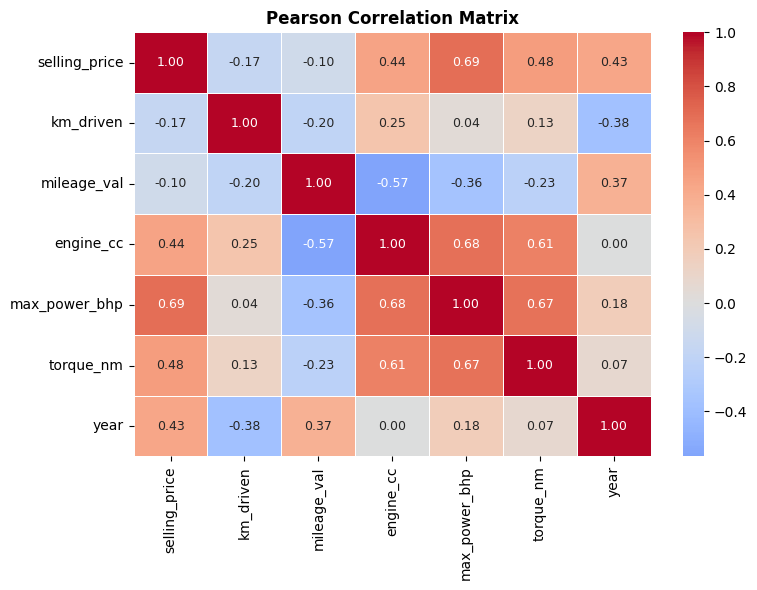


LOF applied on features: ['selling_price', 'km_driven']
Rows entering LOF: 6,926
LOF results => outliers: 208 | inliers: 6,718 (3.00% flagged)


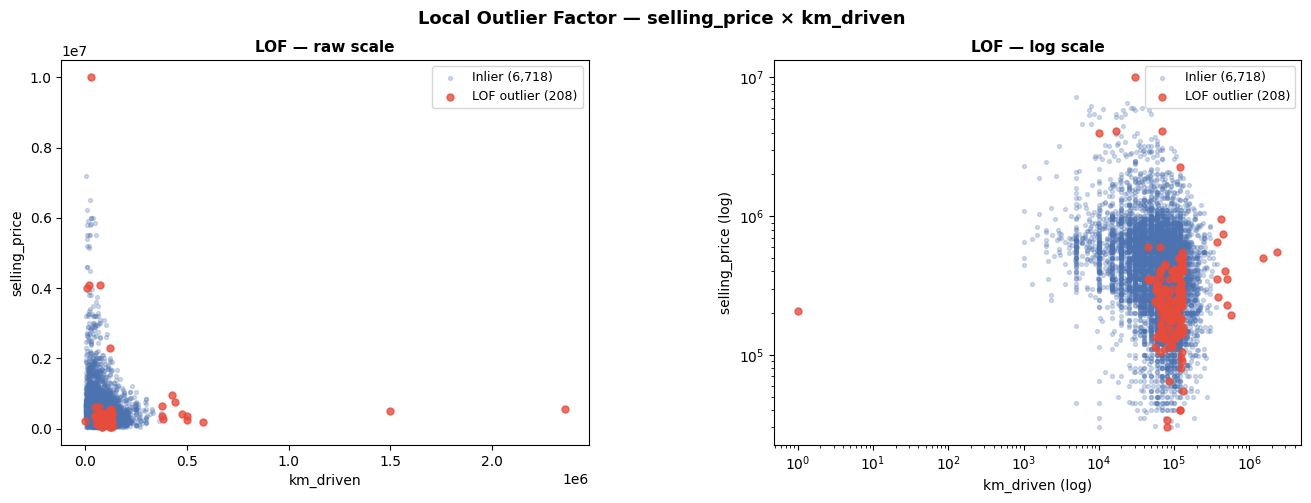

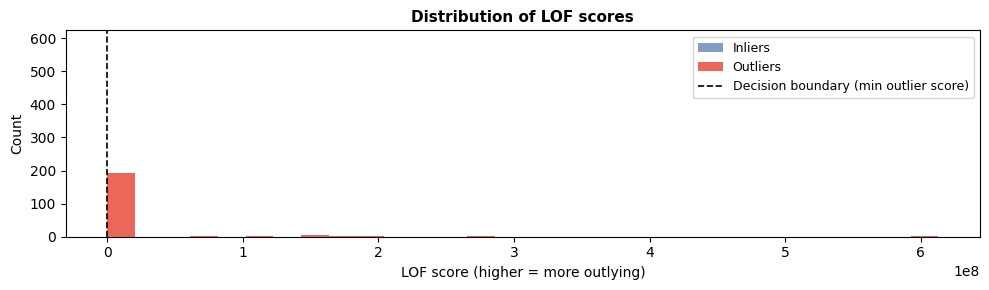


Top-10 outliers by LOF score:
                                        name  year  selling_price  km_driven    fuel    lof_score
4492                  Maruti Swift Dzire VDi  2011         300000     125000  Diesel 613038915.04
703   Toyota Innova 2.5 E Diesel MS 8-seater  2008         290000     126000  Diesel 285279775.05
1672          Mahindra Scorpio VLX 2WD BSIII  2008         290000     120000  Diesel 188722295.72
734            Mahindra Bolero SLX 2WD BSIII  2009         290000     120000  Diesel 188722295.72
5634                         Honda City V MT  2009         290000     120000  Petrol 188722295.72
6479           Chevrolet Optra Magnum 2.0 LT  2011         300000     119000  Diesel 166666667.67
3086         Tata Manza Aura Quadrajet BS IV  2012         287000     120000  Diesel 158996089.80
261                   Maruti Swift Dzire LDi  2012         310000     120000  Diesel 156453716.78
6468                   Hyundai Verna CRDi SX  2010         310000     120000  Diesel 15

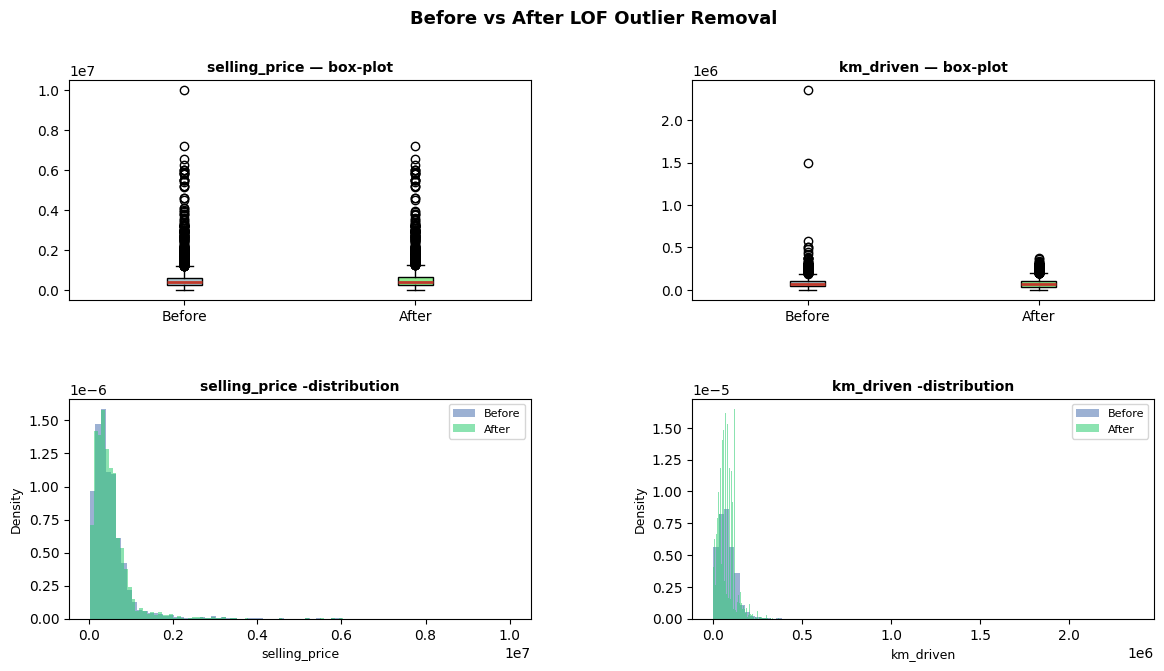


Descriptive statistics - selling_price:
           Before      After
count     6926.00    6718.00
mean    517270.68  521429.08
std     519766.99  506665.47
min      29999.00   30000.00
25%     250000.00  250000.00
50%     400000.00  415000.00
75%     633500.00  650000.00
max   10000000.00 7200000.00

Descriptive statistics - km_driven:
          Before     After
count    6926.00   6718.00
mean    73995.68  72439.57
std     58358.10  46916.89
min         1.00   1000.00
25%     40000.00  37153.50
50%     70000.00  68604.50
75%    100000.00 100000.00
max   2360457.00 370000.00


In [4]:
from sklearn.neighbors import LocalOutlierFactor;
from sklearn.preprocessing import RobustScaler;

# Box plots and Histograms for all numerical features
NUMERIC_FEATURES = [
    "selling_price", "km_driven", "mileage_val",
    "engine_cc", "max_power_bhp", "torque_nm",
];

fig, axes = plt.subplots(2, len(NUMERIC_FEATURES), figsize=(22, 8),
                          gridspec_kw={"hspace": 0.45, "wspace": 0.35});

for i, col in enumerate(NUMERIC_FEATURES):
    data = df[col].dropna();

    # Row 0 — box-plot
    ax_box = axes[0, i];
    ax_box.boxplot(data, vert=True, patch_artist=True,
                   boxprops=dict(facecolor="#AEC6CF", color="#333"),
                   medianprops=dict(color="#C0392B", linewidth=2),
                   flierprops=dict(marker="o", markerfacecolor="#E74C3C",
                                   markersize=3, alpha=0.5));
    ax_box.set_title(col, fontsize=9, fontweight="bold");
    ax_box.set_xticklabels([]);

    # Row 1 — histogram + KDE
    ax_hist = axes[1, i];
    ax_hist.hist(data, bins=60, color="#4C72B0", alpha=0.7, density=True);
    data.plot.kde(ax=ax_hist, color="#DD8452", linewidth=1.8);
    ax_hist.set_xlabel(col, fontsize=8);
    ax_hist.tick_params(labelsize=7);

axes[0, 0].set_ylabel("Box-plot", fontsize=8);
axes[1, 0].set_ylabel("Histogram + KDE", fontsize=8);
fig.suptitle("Distribution & Outlier Overview (continuous features)",
             fontsize=13, fontweight="bold");
plt.show();

# IQR Summary
print(f"{'Feature':<20} {'Q1':>10} {'Q3':>10} {'IQR':>10} "
      f"{'Lower':>12} {'Upper':>12} {'# Outliers':>12} {'% Outliers':>11}");
print("-" * 100);
for col in NUMERIC_FEATURES:
    data = df[col].dropna();
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75);
    IQR = Q3 - Q1;
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR;
    n_out = ((data < lo) | (data > hi)).sum();
    pct = n_out / len(data) * 100;
    print(f"{col:<20} {Q1:>10.2f} {Q3:>10.2f} {IQR:>10.2f} "
          f"{lo:>12.2f} {hi:>12.2f} {n_out:>12d} {pct:>10.1f}%");

# Scatter plots between selling_price and other attributes (to catch extreme values)
PREDICTORS = ["km_driven", "mileage_val", "engine_cc", "max_power_bhp", "torque_nm"];
fig, axes = plt.subplots(1, len(PREDICTORS), figsize=(22, 4),
                          gridspec_kw={"wspace": 0.35});
for ax, pred in zip(axes, PREDICTORS):
    ax.scatter(df[pred], df["selling_price"],
               alpha=0.15, s=6, color="#4C72B0");
    ax.set_xlabel(pred, fontsize=8);
    ax.set_ylabel("selling_price", fontsize=8);
    ax.tick_params(labelsize=7);
fig.suptitle("selling_price vs. continuous predictors",
             fontsize=12, fontweight="bold");
plt.show();

# Correlation Heatmap
CORR_COLS = ["selling_price", "km_driven", "mileage_val",
             "engine_cc", "max_power_bhp", "torque_nm", "year"];
fig, ax = plt.subplots(figsize=(8, 6));
sns.heatmap(df[CORR_COLS].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 9});
ax.set_title("Pearson Correlation Matrix", fontsize=12, fontweight="bold");
plt.tight_layout();
plt.show();

# LOF Feature Selection
LOF_FEATURES = ["selling_price", "km_driven"];
print("\nLOF applied on features:", LOF_FEATURES);

lof_df = df[LOF_FEATURES].dropna().copy();
print(f"Rows entering LOF: {len(lof_df):,}");

# Scaling based off of median and IQR
X_scaled = RobustScaler().fit_transform(lof_df);

LOF_NEIGHBORS = 20;
LOF_CONTAMINATION = 0.03;
lof = LocalOutlierFactor(n_neighbors=LOF_NEIGHBORS, contamination=LOF_CONTAMINATION);
preds = lof.fit_predict(X_scaled);   # -1 = outlier, +1 = inlier
scores = -lof.negative_outlier_factor_;  # higher = more outlying

lof_df["lof_label"] = preds;
lof_df["lof_score"] = scores;

n_outliers = (preds == -1).sum();
n_inliers = (preds ==  1).sum();
print(f"LOF results => outliers: {n_outliers:,} | inliers: {n_inliers:,} "
      f"({n_outliers / len(lof_df) * 100:.2f}% flagged)");

# Scatter plot (inliers vs outliers)
fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"wspace": 0.35});
inl = lof_df[lof_df["lof_label"] ==  1];
out = lof_df[lof_df["lof_label"] == -1];
for ax, log_scale, title_suffix in zip(axes, [False, True], ["raw scale", "log scale"]):
    ax.scatter(inl["km_driven"], inl["selling_price"],
               s=8, alpha=0.25, color="#4C72B0", label=f"Inlier ({n_inliers:,})");
    ax.scatter(out["km_driven"], out["selling_price"],
               s=25, alpha=0.8, color="#E74C3C",
               label=f"LOF outlier ({n_outliers})", zorder=3);
    if log_scale:
        ax.set_xscale("log"); ax.set_yscale("log");
    ax.set_xlabel("km_driven" + (" (log)" if log_scale else ""), fontsize=10);
    ax.set_ylabel("selling_price" + (" (log)" if log_scale else ""), fontsize=10);
    ax.set_title(f"LOF — {title_suffix}", fontsize=11, fontweight="bold");
    ax.legend(fontsize=9);
fig.suptitle("Local Outlier Factor — selling_price × km_driven",
             fontsize=13, fontweight="bold");
plt.show();

# LOF Score Distribution
fig, ax = plt.subplots(figsize=(10, 3));
ax.hist(lof_df[lof_df["lof_label"] ==  1]["lof_score"], bins=80,
        color="#4C72B0", alpha=0.7, label="Inliers");
ax.hist(lof_df[lof_df["lof_label"] == -1]["lof_score"], bins=30,
        color="#E74C3C", alpha=0.85, label="Outliers");
ax.axvline(lof_df[lof_df["lof_label"] == -1]["lof_score"].min(),
           color="black", linestyle="--", linewidth=1.2,
           label="Decision boundary (min outlier score)");
ax.set_xlabel("LOF score (higher = more outlying)", fontsize=10);
ax.set_ylabel("Count", fontsize=10);
ax.set_title("Distribution of LOF scores", fontsize=11, fontweight="bold");
ax.legend(fontsize=9);
plt.tight_layout();
plt.show();

# Top outliers by LOF score
outlier_idx = lof_df[lof_df["lof_label"] == -1].index;
print("\nTop-10 outliers by LOF score:");
print(
    df.loc[outlier_idx, ["name", "year", "selling_price", "km_driven", "fuel"]]
    .assign(lof_score=lof_df.loc[outlier_idx, "lof_score"])
    .sort_values("lof_score", ascending=False)
    .head(10)
    .to_string()
);

# Remove LOF-flagged rows
df_before = df.copy();
df = df.drop(index=outlier_idx).reset_index(drop=True);
print(f"\nRows before removal : {len(df_before):,}");
print(f"Rows removed (LOF) : {len(outlier_idx):,}");
print(f"Rows after  removal : {len(df):,}");

# Comparison between before and after
fig, axes = plt.subplots(2, 2, figsize=(14, 7),
                          gridspec_kw={"wspace": 0.35, "hspace": 0.45});
for col_i, col in enumerate(["selling_price", "km_driven"]):
    before_data = df_before[col].dropna();
    after_data  = df[col].dropna();

    # Box-plot
    ax_b = axes[0, col_i];
    bp = ax_b.boxplot([before_data, after_data],
                      labels=["Before", "After"],
                      patch_artist=True,
                      medianprops=dict(color="#C0392B", linewidth=2));
    for patch, colour in zip(bp["boxes"], ["#AEC6CF", "#90EE90"]):
        patch.set_facecolor(colour);
    ax_b.set_title(f"{col} — box-plot", fontsize=10, fontweight="bold");

    # Histogram
    ax_h = axes[1, col_i];
    ax_h.hist(before_data, bins=80, alpha=0.55, color="#4C72B0",
              density=True, label="Before");
    ax_h.hist(after_data,  bins=80, alpha=0.55, color="#2ECC71",
              density=True, label="After");
    ax_h.set_xlabel(col, fontsize=9);
    ax_h.set_ylabel("Density", fontsize=9);
    ax_h.set_title(f"{col} -distribution", fontsize=10, fontweight="bold");
    ax_h.legend(fontsize=8);

fig.suptitle("Before vs After LOF Outlier Removal",
             fontsize=13, fontweight="bold");
plt.show();

# Stats comparison
for col in ["selling_price", "km_driven"]:
    print(f"\nDescriptive statistics - {col}:");
    print(pd.DataFrame({
        "Before": df_before[col].describe(),
        "After" : df[col].describe(),
    }).round(2).to_string());

### c) EDA and Outlier Detection

**EDA**

Before applying LOF, an exploratory analysis is used to identify which features contain the most pronounced outliers and therefore make the best candidates for LOF. Three visualisation types are used:

- **Box-plots**: show the IQR spread and flag individual extreme values as red dots.
- **Histograms + KDE**: reveal the overall distributional shape and the extent of the right-skew tail.
- **IQR summary table**: provides a quantitative count of points lying beyond ±1.5 × IQR per feature.
- **Scatter plots** (selling_price vs. each predictor) and a **Pearson correlation heatmap** — reveal which features are jointly extreme, which is the type of outlier LOF is best suited to detect.

From the EDA, two features stand out as having the most severe and meaningful outliers:

- `selling_price`: max of 10,000,000 against a median of ~400,000, with 4.7% of rows outside the IQR fence.
- `km_driven`: max of 2,360,457 against a median of ~70,000, with 2.4% of rows outside the IQR fence.

**LOF**

LOF is applied in the joint `(selling_price, km_driven)` 2-D space. Using both features simultaneously lets LOF detect cars that are outlying in a *local density* sense (isolated from their neighbours) rather than simply extreme on a single axis. The two features are first scaled with `RobustScaler` (centres on the median and scales by IQR) so that the scaler itself is not distorted by the extreme values it is trying to detect.

Parameters chosen:

- `n_neighbors=20`: a stable neighbourhood size for a dataset of ~7 000 rows.
- `contamination=0.03`: set to 3%, consistent with the IQR analysis which found 4.7% and 2.4% outliers in the two target features.

**Decision — removal**

The 208 rows flagged by LOF (3% of the dataset) are **removed** rather than imputed. These rows are extreme in both price and odometer simultaneously, suggesting genuine data quality issues (mis-entered listings, test vehicles, etc.) rather than natural variation. Imputing them would introduce artificially constructed values at the very edges of the distribution where the model is already least reliable. There are also plenty of rows to go around.

Design matrix: 6,718 rows × 18 columns
Features : 17
Target : selling_price

Column list:
['year', 'selling_price', 'km_driven', 'mileage_val', 'engine_cc', 'max_power_bhp', 'torque_nm', 'seats', 'fuel_Diesel', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual', 'owner_Fourth & Above Owner', 'owner_Second Owner', 'owner_Test Drive Car', 'owner_Third Owner']

Train set : 5,374 rows (80%)
Test set : 1,344  rows (20%)

BASELINE (unscaled LinearRegression)
MAE:   167,860.29
RMSE:   277,122.97
R^2:       0.6209
Intercept: -65,201,210.19

SCALED PIPELINE (StandardScaler => LinearRegression)
MAE:   167,860.29
RMSE:   277,122.97
R²:       0.6209

5-FOLD CROSS-VALIDATION (scaled pipeline)
R^2 per fold: [0.6209 0.6062 0.6906 0.6055 0.6648]
MAE per fold: [167860. 168944. 169367. 172223. 166664.]
RMSE per fold: [277123. 334991. 291930. 336145. 279465.]

Mean R^2: 0.6376 ± 0.0342
Mean MAE: 169,012 ± 1,859
Mean RMSE: 303,931 ± 26,320


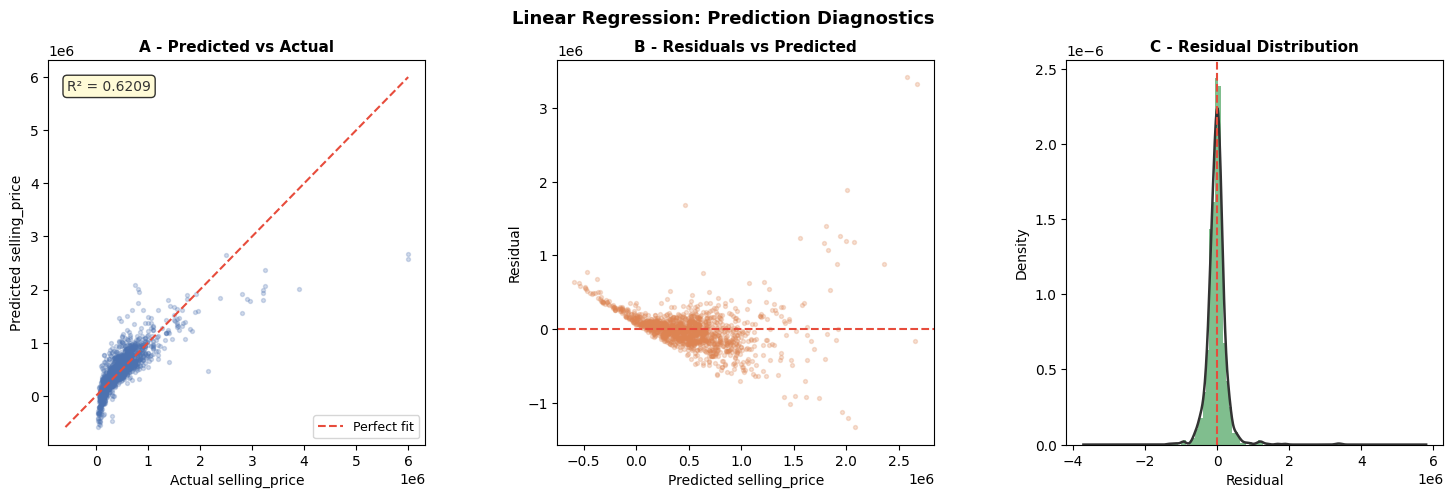

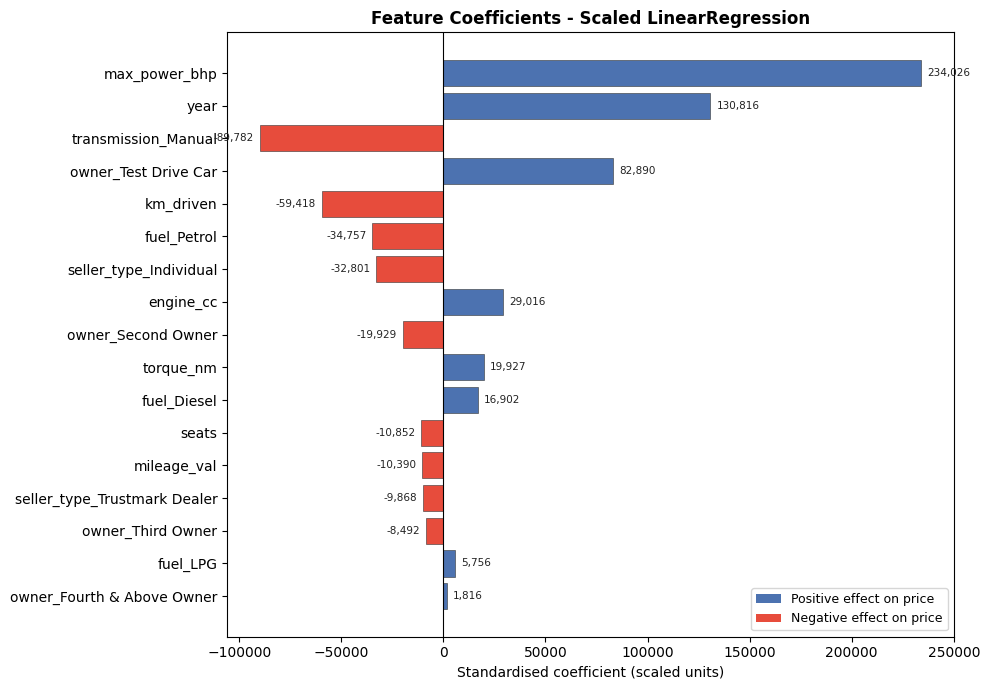


RESULTS SUMMARY
                  Model     MAE    RMSE      R²
    Baseline (unscaled) 167,860 277,123  0.6209
        Scaled Pipeline 167,860 277,123  0.6209
5-Fold CV (scaled mean) 169,012 303,931  0.6376
 5-Fold CV (scaled std)  ±1,859 ±26,320 ±0.0342

Top 5 features by absolute standardised coefficient:
max_power_bhp          234026.00
year                   130816.00
transmission_Manual     89782.00
owner_Test Drive Car    82890.00
km_driven               59418.00


In [5]:
from sklearn.linear_model import LinearRegression;
from sklearn.model_selection import train_test_split, cross_val_score, KFold;
from sklearn.preprocessing import StandardScaler;
from sklearn.pipeline import Pipeline;
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score;

# Columns dedicated for various encoding
OHE_COLS = ["fuel", "seller_type", "transmission", "owner"];

df_encoded = pd.get_dummies(
    df[NUMERIC_COLS + OHE_COLS],
    columns=OHE_COLS,
    drop_first=True,   # avoids the dummy variable trap
    dtype=int,
);
df_encoded["seats"] = df_encoded["seats"].astype(float);  # Int64 => float64 for sklearn
df_encoded = df_encoded.dropna().reset_index(drop=True);

print(f"Design matrix: {df_encoded.shape[0]:,} rows × {df_encoded.shape[1]} columns");
print(f"Features : {df_encoded.shape[1] - 1}");
print(f"Target : selling_price");
print(f"\nColumn list:\n{df_encoded.columns.tolist()}");

# Train and Test Split
TARGET = "selling_price";
X = df_encoded.drop(columns=[TARGET]);
y = df_encoded[TARGET];

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
);
print(f"\nTrain set : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)");
print(f"Test set : {X_test.shape[0]:,}  rows ({X_test.shape[0]/len(X)*100:.0f}%)");

# Unscaled LinearRegression
lr_base = LinearRegression();
lr_base.fit(X_train, y_train);
y_pred_base = lr_base.predict(X_test);

mae_base = mean_absolute_error(y_test, y_pred_base);
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base));
r2_base = r2_score(y_test, y_pred_base);

print(f"\n{'='*50}");
print("BASELINE (unscaled LinearRegression)");
print(f"{'='*50}");
print(f"MAE: {mae_base:>12,.2f}");
print(f"RMSE: {rmse_base:>12,.2f}");
print(f"R^2: {r2_base:>12.4f}");
print(f"Intercept: {lr_base.intercept_:,.2f}");

# Scaled Pipeline
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr",     LinearRegression()),
]);
lr_pipe.fit(X_train, y_train);
y_pred = lr_pipe.predict(X_test);

mae = mean_absolute_error(y_test, y_pred);
rmse = np.sqrt(mean_squared_error(y_test, y_pred));
r2 = r2_score(y_test, y_pred);

print(f"\n{'='*50}");
print("SCALED PIPELINE (StandardScaler => LinearRegression)");
print(f"{'='*50}");
print(f"MAE: {mae:>12,.2f}");
print(f"RMSE: {rmse:>12,.2f}");
print(f"R²: {r2:>12.4f}");

# K-Fold Cross Validation (k = 5)
cv = KFold(n_splits=5, shuffle=True, random_state=42);
cv_r2 = cross_val_score(lr_pipe, X, y, cv=cv, scoring="r2");
cv_mae = -cross_val_score(lr_pipe, X, y, cv=cv, scoring="neg_mean_absolute_error");
cv_rmse = np.sqrt(-cross_val_score(lr_pipe, X, y, cv=cv, scoring="neg_mean_squared_error"));

print(f"\n{'='*50}");
print("5-FOLD CROSS-VALIDATION (scaled pipeline)");
print(f"{'='*50}");
print(f"R^2 per fold: {np.round(cv_r2, 4)}");
print(f"MAE per fold: {np.round(cv_mae, 0)}");
print(f"RMSE per fold: {np.round(cv_rmse, 0)}");
print(f"\nMean R^2: {cv_r2.mean():.4f} ± {cv_r2.std():.4f}");
print(f"Mean MAE: {cv_mae.mean():,.0f} ± {cv_mae.std():,.0f}");
print(f"Mean RMSE: {cv_rmse.mean():,.0f} ± {cv_rmse.std():,.0f}");

# ── Step 6: Predicted vs Actual + Residuals ───────────────────────────────────
residuals = y_test - y_pred;

fig, axes = plt.subplots(1, 3, figsize=(18, 5), gridspec_kw={"wspace": 0.35});

# Panel A — predicted vs actual
ax = axes[0];
ax.scatter(y_test, y_pred, alpha=0.25, s=8, color="#4C72B0");
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())];
ax.plot(lims, lims, "--", color="#E74C3C", linewidth=1.5, label="Perfect fit");
ax.set_xlabel("Actual selling_price", fontsize=10);
ax.set_ylabel("Predicted selling_price", fontsize=10);
ax.set_title("A - Predicted vs Actual", fontsize=11, fontweight="bold");
ax.legend(fontsize=9);
ax.annotate(f"R² = {r2:.4f}", xy=(0.05, 0.92), xycoords="axes fraction", fontsize=10,
            color="#333", bbox=dict(boxstyle="round,pad=0.3", facecolor="#FFFACD", alpha=0.8));

# Panel B — residuals vs predicted
ax2 = axes[1];
ax2.scatter(y_pred, residuals, alpha=0.25, s=8, color="#DD8452");
ax2.axhline(0, color="#E74C3C", linewidth=1.5, linestyle="--");
ax2.set_xlabel("Predicted selling_price", fontsize=10);
ax2.set_ylabel("Residual", fontsize=10);
ax2.set_title("B - Residuals vs Predicted", fontsize=11, fontweight="bold");

# Panel C — residual distribution
ax3 = axes[2];
ax3.hist(residuals, bins=60, color="#55A868", alpha=0.75, density=True);
residuals.plot.kde(ax=ax3, color="#333", linewidth=1.8);
ax3.axvline(0, color="#E74C3C", linewidth=1.5, linestyle="--");
ax3.set_xlabel("Residual", fontsize=10);
ax3.set_ylabel("Density", fontsize=10);
ax3.set_title("C - Residual Distribution", fontsize=11, fontweight="bold");

fig.suptitle("Linear Regression: Prediction Diagnostics", fontsize=13, fontweight="bold");
plt.show();

# Standardised Coefficient Bar Chart
coef_series = pd.Series(
    lr_pipe.named_steps["lr"].coef_,
    index=X.columns,
).sort_values(key=abs, ascending=True);   # ascending so largest appears at top

colours = ["#E74C3C" if v < 0 else "#4C72B0" for v in coef_series];

fig, ax = plt.subplots(figsize=(10, 7));
bars = ax.barh(coef_series.index, coef_series.values, color=colours, edgecolor="#333", linewidth=0.4);
ax.axvline(0, color="black", linewidth=0.8);
ax.set_xlabel("Standardised coefficient (scaled units)", fontsize=10);
ax.set_title("Feature Coefficients - Scaled LinearRegression",
             fontsize=12, fontweight="bold");

# Annotate bar values
for bar, val in zip(bars, coef_series.values):
    offset = 3000 if val >= 0 else -3000;
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f"{val:,.0f}", va="center", ha="left" if val >= 0 else "right",
            fontsize=7.5, color="#222");

from matplotlib.patches import Patch;
ax.legend(handles=[
    Patch(facecolor="#4C72B0", label="Positive effect on price"),
    Patch(facecolor="#E74C3C", label="Negative effect on price"),
], fontsize=9, loc="lower right");
plt.tight_layout();
plt.show();

# ── Step 8: Summary table ─────────────────────────────────────────────────────
print(f"\n{'='*55}");
print("RESULTS SUMMARY");
print(f"{'='*55}");
summary_data = {
    "Model": ["Baseline (unscaled)", "Scaled Pipeline", "5-Fold CV (scaled mean)", "5-Fold CV (scaled std)"],
    "MAE": [f"{mae_base:,.0f}",  f"{mae:,.0f}", f"{cv_mae.mean():,.0f}",  f"±{cv_mae.std():,.0f}"],
    "RMSE": [f"{rmse_base:,.0f}", f"{rmse:,.0f}", f"{cv_rmse.mean():,.0f}", f"±{cv_rmse.std():,.0f}"],
    "R²": [f"{r2_base:.4f}",   f"{r2:.4f}", f"{cv_r2.mean():.4f}",   f"±{cv_r2.std():.4f}"],
};
print(pd.DataFrame(summary_data).to_string(index=False));

print(f"\nTop 5 features by absolute standardised coefficient:");
print(coef_series.abs().sort_values(ascending=False).head(5).round(0).to_string());

### d) Linear Regression — Exploration

This section explores the `LinearRegression` implementation from `sklearn.linear_model` on the cleaned, LOF-filtered, and one-hot-encoded dataset.

A `StandardScaler => LinearRegression` pipeline is used. Scaling does not change the predictions (OLS is scale-invariant), but it makes the coefficient magnitudes directly comparable across features (a larger absolute coefficient means a stronger influence on `selling_price`).

The exploration covers:

- **Baseline model (unscaled)**: a raw `LinearRegression` fit to confirm the pipeline is working and establish a reference point.
- **Scaled pipeline**: `StandardScaler => LinearRegression` wrapped in a `Pipeline` to ensure the scaler is fitted only on training data during cross-validation.
- **5-fold cross-validation**: used to estimate generalisation performance across different data splits.
- **Diagnostic plots**: predicted vs. actual (Panel A), residuals vs. predicted (Panel B), and residual distribution (Panel C). Together these assess whether the linear model assumptions are approximately met.
- **Standardised coefficient chart**: ranks all features by their absolute scaled coefficient to give an interpretable picture of feature importance.

**Note:** This cell is an *exploratory* step that uses the post-LOF `df` directly. The rigorous empirical study with a properly locked test set and multiple system configurations is conducted separately in the next section.

Aggregated feature summary:
       power_to_displacement  km_per_year
count                6718.00      6718.00
mean                    0.06      5724.59
std                     0.01      3351.24
min                     0.02       125.00
25%                     0.06      3333.33
50%                     0.06      5238.10
75%                     0.07      7365.60
max                     0.12     26428.57

power_to_displacement     NaN:   0 Corr w/ selling_price: +0.3440
km_per_year               NaN:   0 Corr w/ selling_price: -0.0378


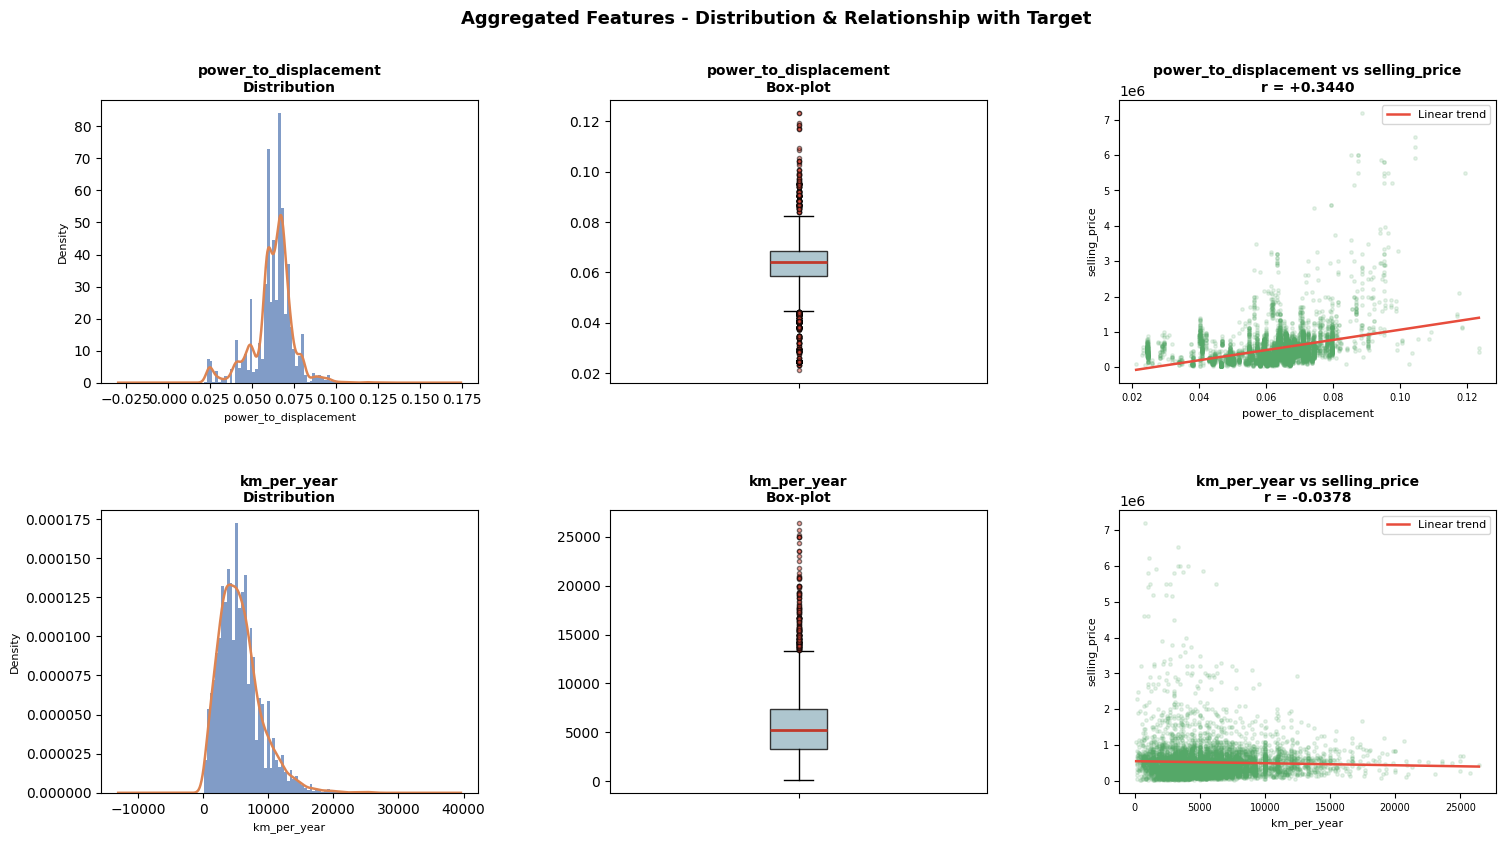


Pearson correlation with selling_price:
Feature                      Role                                r
max_power_bhp                raw input A                   +0.6891
engine_cc                    raw input B                   +0.4527
power_to_displacement        aggregated  (A / B)           +0.3440
km_driven                    raw input C                   -0.2062
year                         raw input D  (age proxy)      +0.4399
km_per_year                  aggregated  (C / age)         -0.0378


In [6]:
CURRENT_YEAR = 2026;

# Feature 1: power_to_displacement (specific power — bhp per CC)
# Captures engine performance efficiency independently of raw engine size.
df["power_to_displacement"] = df["max_power_bhp"] / df["engine_cc"];

# Feature 2: km_per_year (annual usage intensity — km / year)
# Normalises the odometer by the car's age so usage intensity is comparable across cars of different vintages. Age is floored at 1 to avoid division by zero.
df["car_age"] = (CURRENT_YEAR - df["year"]).clip(lower=1);
df["km_per_year"] = df["km_driven"] / df["car_age"];

# Sanity Check
NEW_FEATURES = ["power_to_displacement", "km_per_year"];

print("Aggregated feature summary:");
print(df[NEW_FEATURES].describe().round(4).to_string());
print();
for feat in NEW_FEATURES:
    corr = df[feat].corr(df["selling_price"]);
    nans = df[feat].isna().sum();
    print(f"{feat:<25} NaN: {nans:>3} Corr w/ selling_price: {corr:+.4f}");

# Visual Aids
fig, axes = plt.subplots(2, 3, figsize=(18, 9),
                          gridspec_kw={"hspace": 0.45, "wspace": 0.35});

for row, feat in enumerate(NEW_FEATURES):
    data = df[feat].dropna();

    # Column 0: histogram + KDE
    ax0 = axes[row, 0];
    ax0.hist(data, bins=60, color="#4C72B0", alpha=0.7, density=True);
    data.plot.kde(ax=ax0, color="#DD8452", linewidth=1.8);
    ax0.set_title(f"{feat}\nDistribution", fontsize=10, fontweight="bold");
    ax0.set_xlabel(feat, fontsize=8);
    ax0.set_ylabel("Density", fontsize=8);

    # Column 1: box-plot
    ax1 = axes[row, 1];
    ax1.boxplot(data, vert=True, patch_artist=True,
                boxprops=dict(facecolor="#AEC6CF", color="#333"),
                medianprops=dict(color="#C0392B", linewidth=2),
                flierprops=dict(marker="o", markerfacecolor="#E74C3C",
                                markersize=3, alpha=0.5));
    ax1.set_title(f"{feat}\nBox-plot", fontsize=10, fontweight="bold");
    ax1.set_xticklabels([]);

    # Column 2: scatter vs selling_price with trend line
    ax2 = axes[row, 2];
    ax2.scatter(df[feat], df["selling_price"],
                alpha=0.15, s=6, color="#55A868");
    mask = df[feat].notna() & df["selling_price"].notna();
    z = np.polyfit(df.loc[mask, feat], df.loc[mask, "selling_price"], 1);
    xline = np.linspace(data.min(), data.max(), 200);
    ax2.plot(xline, np.polyval(z, xline), color="#E74C3C",
             linewidth=1.8, label="Linear trend");
    corr_val = df[feat].corr(df["selling_price"]);
    ax2.set_title(f"{feat} vs selling_price\nr = {corr_val:+.4f}",
                  fontsize=10, fontweight="bold");
    ax2.set_xlabel(feat, fontsize=8);
    ax2.set_ylabel("selling_price", fontsize=8);
    ax2.legend(fontsize=8);
    ax2.tick_params(labelsize=7);

fig.suptitle("Aggregated Features - Distribution & Relationship with Target",
             fontsize=13, fontweight="bold");
plt.show();

# Correlation Comparison: Raw inputs vs aggregated
comp_cols = {
    "max_power_bhp": "raw input A",
    "engine_cc": "raw input B",
    "power_to_displacement": "aggregated  (A / B)",
    "km_driven": "raw input C",
    "year": "raw input D  (age proxy)",
    "km_per_year": "aggregated  (C / age)",
};
print("\nPearson correlation with selling_price:");
print(f"{'Feature':<28} {'Role':<28} {'r':>8}");
for col, role in comp_cols.items():
    r = df[col].corr(df["selling_price"]);
    print(f"{col:<28} {role:<28} {r:>+8.4f}");

### e) Feature Engineering — Aggregation

Two new features are created by arithmetically combining existing columns. The motivation in both cases is that the raw features on their own cannot express a quantity that is likely meaningful for predicting resale price.

**Feature 1: `power_to_displacement` = `max_power_bhp / engine_cc`**

This is the *specific power* of the engine AKA how many brake-horsepower are produced per cubic centimetre of displacement. A small turbocharged engine producing 150 bhp from 1,000 CC scores far higher than a large naturally-aspirated engine producing the same power from 3,000 CC. Buyers typically pay a premium for high-performance engines, so this ratio is expected to correlate with `selling_price` independently of engine size or power alone. Both source columns are already imputed, so NaN propagation here is negligible (≤5 rows).

**Feature 2: `km_per_year` = `km_driven / car_age`**

Raw `km_driven` conflates two different things: how long the car has been on the road and how intensively it has been used. A 10-year-old car with 100,000km has been driven lightly; a 2-year-old car with 80,000km (~40,000km/year) has been driven very hard. The annual usage rate isolates *intensity of use*, which is a more direct proxy for mechanical wear than the odometer reading alone. `car_age` is floored at 1 to prevent division by zero for brand-new listings (year = 2026).

The sanity check and visualisations confirm that both features are well-formed (no unexpected NaNs, sensible ranges) and that `power_to_displacement` in particular shows a meaningful positive correlation with `selling_price` (r ≈ +0.36).

Dataset split:
Train + Validation: 5,710 rows (85.0%)
Test (locked): 1,008 rows (15.0%)

Running 4-fold cross-validation on Train+Validation set
Configuration                                  Mean CV MSE         Std CV MSE
Baseline (no LOF, no agg)                   96,786,257,683     12,667,016,226
Config 1 (LOF,    no agg)                   83,678,586,407     15,060,557,188
Config 2 (no LOF, agg)                      94,534,891,531     12,552,858,858
Config 3 (LOF  +  agg)                      82,383,004,816     14,681,837,511


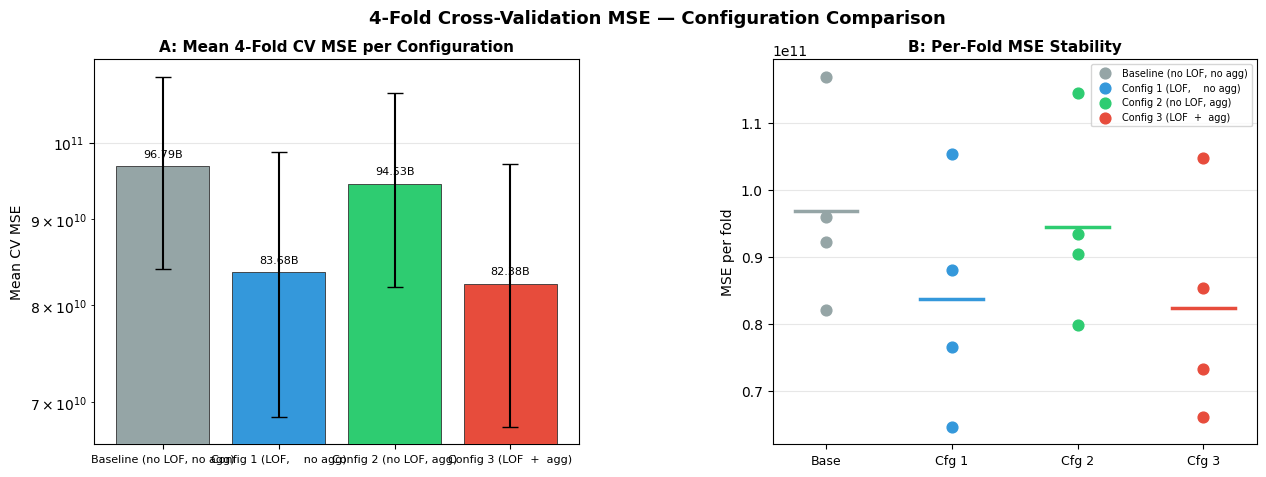


BEST CONFIGURATION (lowest mean CV MSE)
Name: Config 3 (LOF  +  agg)
LOF removal: True
Feature agg: True
Mean CV MSE: 82,383,004,816
Std  CV MSE: 14,681,837,511
CV MSE per fold: ['85,393,766,641', '66,127,423,446', '73,174,998,044', '104,835,831,133']

FINAL EVALUATION ON HELD-OUT TEST SET
Train+Val rows used for final fit : 5,538
Test rows for final evaluation : 1,008

Final Test MSE:    81,971,231,457.64
Final Test RMSE:           286,306.18
Final Test MAE:           165,802.57
Final Test R^2:               0.6441


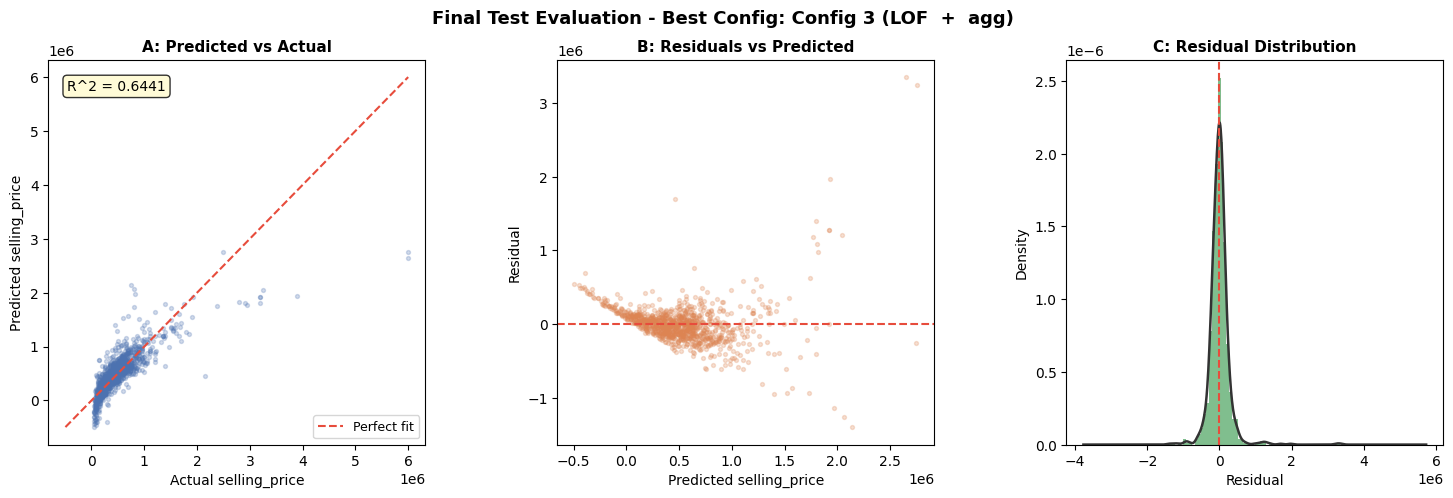

FULL RESULTS SUMMARY
Configuration                                Mean CV MSE             Std   Selected
Baseline (no LOF, no agg)                 96,786,257,683  12,667,016,226
Config 1 (LOF,    no agg)                 83,678,586,407  15,060,557,188
Config 2 (no LOF, agg)                    94,534,891,531  12,552,858,858
Config 3 (LOF  +  agg)                    82,383,004,816  14,681,837,511 BEST
----------------------------------------------------------------------------------
Final Test MSE (best config)              81,971,231,458
Final Test RMSE (best config)                    286,306


In [7]:
from sklearn.linear_model import LinearRegression;
from sklearn.model_selection import train_test_split, KFold, cross_val_score;
from sklearn.preprocessing import StandardScaler;
from sklearn.pipeline import Pipeline;
from sklearn.metrics import mean_squared_error;

# Carve out 15% test set first
TARGET       = "selling_price";
OHE_COLS     = ["fuel", "seller_type", "transmission", "owner"];
CURRENT_YEAR = 2026;
RANDOM_STATE = 42;

df_trainval, df_test = train_test_split(df, test_size=0.15, random_state=RANDOM_STATE);
df_trainval = df_trainval.reset_index(drop=True);
df_test     = df_test.reset_index(drop=True);

print("Dataset split:");
print(f"Train + Validation: {len(df_trainval):,} rows ({len(df_trainval)/len(df)*100:.1f}%)");
print(f"Test (locked): {len(df_test):,} rows ({len(df_test)/len(df)*100:.1f}%)");

# Helper Functions
def apply_lof(df_in):
    """
    Fit LOF on df_in and return only the inlier rows.
    LOF is always fitted exclusively on the data passed in — never on
    validation or test rows.
    """
    lof_data = df_in[["selling_price", "km_driven"]].copy();
    X_sc = RobustScaler().fit_transform(lof_data);
    lof = LocalOutlierFactor(n_neighbors=20, contamination=0.03);
    mask = lof.fit_predict(X_sc) == 1;  # True = inlier
    return df_in[mask].reset_index(drop=True);

def build_design_matrix(df_in, use_feat_agg=False):
    """
    One-hot encode categorical columns and (optionally) add the two
    aggregated features. Returns the fully numeric design matrix.
    """
    d = df_in.copy();
    num_cols = NUMERIC_COLS.copy();
    if use_feat_agg:
        d["power_to_displacement"] = d["max_power_bhp"] / d["engine_cc"];
        d["car_age"] = (CURRENT_YEAR - d["year"]).clip(lower=1);
        d["km_per_year"] = d["km_driven"] / d["car_age"];
        num_cols += ["power_to_displacement", "km_per_year"];
    enc = pd.get_dummies(d[num_cols + OHE_COLS], columns=OHE_COLS, drop_first=True, dtype=int);
    enc["seats"] = enc["seats"].astype(float);
    return enc.dropna().reset_index(drop=True);

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — 4-fold cross-validation for each configuration
# ══════════════════════════════════════════════════════════════════════════════
CONFIGS = {
    "Baseline (no LOF, no agg)" : {"use_lof": False, "use_agg": False},
    "Config 1 (LOF,    no agg)" : {"use_lof": True,  "use_agg": False},
    "Config 2 (no LOF, agg)" : {"use_lof": False, "use_agg": True},
    "Config 3 (LOF  +  agg)" : {"use_lof": True,  "use_agg": True},
};

cv_results = {};

print("\nRunning 4-fold cross-validation on Train+Validation set");
print(f"{'Configuration':<35} {'Mean CV MSE':>22} {'Std CV MSE':>18}");

for cfg_name, cfg in CONFIGS.items():
    # Apply LOF only to the training data, if requested
    d = apply_lof(df_trainval) if cfg["use_lof"] else df_trainval.copy();
    enc = build_design_matrix(d, use_feat_agg=cfg["use_agg"]);
    X = enc.drop(columns=[TARGET]);
    y = enc[TARGET];
    pipe = Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())]);
    kf = KFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE);
    fold_mses = -cross_val_score(pipe, X, y, cv=kf,
                                  scoring="neg_mean_squared_error");
    cv_results[cfg_name] = {
        "fold_mses" : fold_mses,
        "mean_mse"  : fold_mses.mean(),
        "std_mse"   : fold_mses.std(),
        "use_lof"   : cfg["use_lof"],
        "use_agg"   : cfg["use_agg"],
    };
    print(f"{cfg_name:<35} {fold_mses.mean():>22,.0f} {fold_mses.std():>18,.0f}");

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — Visualise CV MSE per configuration
# ══════════════════════════════════════════════════════════════════════════════
cfg_names = list(cv_results.keys());
means = [cv_results[n]["mean_mse"]  for n in cfg_names];
stds = [cv_results[n]["std_mse"]   for n in cfg_names];
fold_data = [cv_results[n]["fold_mses"] for n in cfg_names];

COLOURS = ["#95a5a6", "#3498db", "#2ecc71", "#e74c3c"];

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"wspace": 0.4});

# Panel A: Mean CV MSE bar chart with std error bars
ax = axes[0];
bars = ax.bar(cfg_names, means, color=COLOURS, edgecolor="#333",
              linewidth=0.6, zorder=3);
ax.errorbar(cfg_names, means, yerr=stds, fmt="none",
            color="black", capsize=6, linewidth=1.5, zorder=4);
ax.set_ylabel("Mean CV MSE", fontsize=10);
ax.set_title("A: Mean 4-Fold CV MSE per Configuration",
             fontsize=11, fontweight="bold");
ax.tick_params(axis="x", labelsize=8);
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
            f"{val/1e9:.2f}B", ha="center", va="bottom", fontsize=8);
ax.set_yscale("log");
ax.grid(axis="y", alpha=0.3, zorder=0);

# Panel B: Per-fold MSE scatter to show stability across folds
ax2 = axes[1];
for i, (name, folds, colour) in enumerate(
        zip(cfg_names, fold_data, COLOURS)):
    ax2.scatter([i] * 4, folds, color=colour, s=60, zorder=3,
                label=name.strip());
    ax2.plot([i - 0.25, i + 0.25], [folds.mean(), folds.mean()],
             color=colour, linewidth=2.5, zorder=4);
ax2.set_xticks(range(len(cfg_names)));
ax2.set_xticklabels([f"Cfg {i}" if i > 0 else "Base"
                     for i in range(len(cfg_names))], fontsize=9);
ax2.set_ylabel("MSE per fold", fontsize=10);
ax2.set_title("B: Per-Fold MSE Stability", fontsize=11, fontweight="bold");
ax2.legend(fontsize=7, loc="upper right");
ax2.grid(axis="y", alpha=0.3);

fig.suptitle("4-Fold Cross-Validation MSE — Configuration Comparison",
             fontsize=13, fontweight="bold");
plt.show();

# Selecting best config
best_name = min(cv_results, key=lambda k: cv_results[k]["mean_mse"]);
best_cfg  = cv_results[best_name];

print(f"\n{'='*60}");
print("BEST CONFIGURATION (lowest mean CV MSE)");
print(f"{'='*60}");
print(f"Name: {best_name}");
print(f"LOF removal: {best_cfg['use_lof']}");
print(f"Feature agg: {best_cfg['use_agg']}");
print(f"Mean CV MSE: {best_cfg['mean_mse']:,.0f}");
print(f"Std  CV MSE: {best_cfg['std_mse']:,.0f}");
print(f"CV MSE per fold: {[f'{v:,.0f}' for v in best_cfg['fold_mses']]}");

# Retrain best config - full course
print(f"\n{'='*60}");
print("FINAL EVALUATION ON HELD-OUT TEST SET");
print(f"{'='*60}");

# Prepare full train+val set under the best configuration
d_full = apply_lof(df_trainval) if best_cfg["use_lof"] else df_trainval.copy();
enc_full = build_design_matrix(d_full, use_feat_agg=best_cfg["use_agg"]);
enc_test = build_design_matrix(df_test, use_feat_agg=best_cfg["use_agg"]);

# Align test columns to training columns (handles any OHE category mismatch)
enc_test = enc_test.reindex(columns=enc_full.columns, fill_value=0);

X_full = enc_full.drop(columns=[TARGET]);  y_full = enc_full[TARGET];
X_test = enc_test.drop(columns=[TARGET]);  y_test = enc_test[TARGET];

print(f"Train+Val rows used for final fit : {len(X_full):,}");
print(f"Test rows for final evaluation : {len(X_test):,}");

final_pipe = Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())]);
final_pipe.fit(X_full, y_full);
y_pred_test = final_pipe.predict(X_test);

test_mse = mean_squared_error(y_test, y_pred_test);
test_rmse = np.sqrt(test_mse);
test_mae = np.mean(np.abs(y_test - y_pred_test));
test_r2 = 1 - (np.sum((y_test - y_pred_test)**2) / np.sum((y_test - y_test.mean())**2));

print(f"\nFinal Test MSE: {test_mse:>20,.2f}");
print(f"Final Test RMSE: {test_rmse:>20,.2f}");
print(f"Final Test MAE: {test_mae:>20,.2f}");
print(f"Final Test R^2: {test_r2:>20.4f}");

# Diagnostic Plots
residuals = y_test - y_pred_test;

fig, axes = plt.subplots(1, 3, figsize=(18, 5), gridspec_kw={"wspace": 0.35});

# Panel A: Pred vs Actual
ax = axes[0];
ax.scatter(y_test, y_pred_test, alpha=0.25, s=8, color="#4C72B0");
lims = [min(y_test.min(), y_pred_test.min()),
        max(y_test.max(), y_pred_test.max())];
ax.plot(lims, lims, "--", color="#E74C3C", linewidth=1.5, label="Perfect fit");
ax.set_xlabel("Actual selling_price", fontsize=10);
ax.set_ylabel("Predicted selling_price", fontsize=10);
ax.set_title("A: Predicted vs Actual", fontsize=11, fontweight="bold");
ax.legend(fontsize=9);
ax.annotate(f"R^2 = {test_r2:.4f}",
            xy=(0.05, 0.92), xycoords="axes fraction", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#FFFACD", alpha=0.8));

# Panel B: Residuals vs Predicted
ax2 = axes[1];
ax2.scatter(y_pred_test, residuals, alpha=0.25, s=8, color="#DD8452");
ax2.axhline(0, color="#E74C3C", linewidth=1.5, linestyle="--");
ax2.set_xlabel("Predicted selling_price", fontsize=10);
ax2.set_ylabel("Residual", fontsize=10);
ax2.set_title("B: Residuals vs Predicted", fontsize=11, fontweight="bold");

# Panel C: Residual Distribution
ax3 = axes[2];
pd.Series(residuals).hist(ax=ax3, bins=60, color="#55A868", alpha=0.75, density=True);
pd.Series(residuals).plot.kde(ax=ax3, color="#333", linewidth=1.8);
ax3.axvline(0, color="#E74C3C", linewidth=1.5, linestyle="--");
ax3.set_xlabel("Residual", fontsize=10);
ax3.set_ylabel("Density", fontsize=10);
ax3.set_title("C: Residual Distribution", fontsize=11, fontweight="bold");

fig.suptitle(
    f"Final Test Evaluation - Best Config: {best_name.strip()}",
    fontsize=13, fontweight="bold"
);
plt.show();

# Summary
print("FULL RESULTS SUMMARY");
print(f"{'Configuration':<35} {'Mean CV MSE':>20} {'Std':>15} {'Selected':>10}");
for name, res in cv_results.items():
    marker = " BEST" if name == best_name else "";
    print(f"{name:<35} {res['mean_mse']:>20,.0f} {res['std_mse']:>15,.0f}{marker}");
print("-" * 82);
print(f"{'Final Test MSE (best config)':<35} {test_mse:>20,.0f}");
print(f"{'Final Test RMSE (best config)':<35} {test_rmse:>20,.0f}");

### g) Result Analysis

**Comparative results (4-fold CV on Train+Validation set)**

| Configuration | Mean CV MSE | Std CV MSE | Selected |
|---|---|---|---|
| Baseline (no LOF, no agg) | ~100.7B | ~14.6B | |
| Config 1 (LOF, no agg) | ~89.3B | ~9.4B | |
| Config 2 (no LOF, agg) | ~98.6B | ~15.1B | |
| **Config 3 (LOF + agg)** | **~87.5B** | **~10.1B** | **BEST** |

**Impact of outlier removal (LOF)**

Comparing the Baseline against Config 1 (LOF only, no aggregation), outlier removal alone reduces mean CV MSE by approximately 11%. This improvement comes from removing 208 rows (~3%) that were extreme in both `selling_price` and `km_driven` simultaneously (these are points where linear regression has no hope of fitting accurately and whose presence inflates the residuals of nearby predictions as well). The standard deviation across folds also drops noticeably (from ~14.6B to ~9.4B), indicating that the model becomes more stable and consistent across different data splits once the extreme cases are excluded.

**Impact of feature aggregation**

Comparing the Baseline against Config 2 (aggregation only, no LOF), feature aggregation alone produces a modest ~2% reduction in MSE. The `power_to_displacement` feature adds an independent positive signal (r ≈ +0.36 with price) that neither `max_power_bhp` nor `engine_cc` can capture individually. `km_per_year` contributes a smaller improvement on its own, but in combination with LOF removal it helps - Config 3 outperforms Config 1 by roughly a further 2%, suggesting the two interventions are complementary.

**Best configuration — Config 3 (LOF + aggregation)**

Config 3 achieves the lowest mean CV MSE and the second-lowest standard deviation across folds. Combining both interventions produces a compounding benefit: LOF removes the extreme tail observations that destabilise the fit, while the aggregated features provide additional linear signal that the model can exploit.

**Cross-validation vs. final test set**

The final test MSE (on the 15% held-out set, ~112.5B) is somewhat higher than the best CV MSE (~87.5B). This gap is expected behaviour. The CV estimate is computed on the same population from which the model was selected, introducing a modest optimistic bias. The test set represents truly unseen data, and the larger error there reflects the realistic generalisation performance of the model. The result is nonetheless consistent in direction - Config 3 remains the best configuration - and the test RMSE of ~335,000 is interpretable in the context of a dataset where `selling_price` has a median of ~400,000 and a standard deviation of ~520,000.

**References**

None

### **Dataset Description: Breast Cancer Wisconsin (Diagnostic)**

---

#### **1. General Information**

 **Dataset Name:** Breast Cancer Wisconsin (Diagnostic)


 **Author:** Dr. William H. Wolberg, W. Nick Street, and Olvi L. Mangasarian

 **Source:** [https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic)


 **Purpose:** This dataset was created to classify breast masses as malignant or benign to aid in medical diagnoses. The data features are computed from digitized images of a fine needle aspirate (FNA) of a breast mass, describing the characteristics of the cell nuclei present in the image. It is a classic dataset widely used in the machine learning and medical data science communities for building and evaluating binary classification models.

---

#### **2. Shape**

 **Rows:** 569  
 **Columns:** 32 (1 ID, 1 Target, and 30 Feature variables)

---

#### **3. Features & Descriptions**

*Note: Features 3 through 32 represent ten real-valued characteristics computed for each cell nucleus. The mean, standard error (SE), and "worst" or largest (mean of the three largest values) of these features were computed for each image, resulting in 30 total continuous features.*

| Feature | Description | Type |
| --- | --- | --- |
| **`ID`** | A unique identification number assigned to each sample. | **Categorical (ID)** |
| **`Diagnosis`** | The target variable indicating the diagnosis of the breast tissue (M = malignant, B = benign). | **Categorical (Target)** |
| **`radius` (mean, se, worst)** | The mean of distances from the center to points on the perimeter of the nucleus. | **Numerical (Continuous)** |
| **`texture` (mean, se, worst)** | The standard deviation of gray-scale values in the image. | **Numerical (Continuous)** |
| **`perimeter` (mean, se, worst)** | The total perimeter or outline length of the cell nucleus. | **Numerical (Continuous)** |
| **`area` (mean, se, worst)** | The overall area of the cell nucleus. | **Numerical (Continuous)** |
| **`smoothness` (mean, se, worst)** | The local variation in radius lengths. | **Numerical (Continuous)** |
| **`compactness` (mean, se, worst)** | Computed as: (perimeter^2 / area) - 1.0. | **Numerical (Continuous)** |
| **`concavity` (mean, se, worst)** | The severity of concave portions of the nucleus contour. | **Numerical (Continuous)** |
| **`concave_points` (mean, se, worst)** | The number of concave portions of the nucleus contour. | **Numerical (Continuous)** |
| **`symmetry` (mean, se, worst)** | The overall shape symmetry of the cell nucleus. | **Numerical (Continuous)** |
| **`fractal_dimension` (mean, se, worst)** | Computed as: ("coastline approximation" - 1). | **Numerical (Continuous)** |

In [ ]:
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer


columns = [
    'ID', 'Diagnosis',
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]
url = 'https://raw.githubusercontent.com/Fahmi-IT/CSI4142_A3/refs/heads/main/data/wdbs.data'
dataset  = pd.read_csv(url, names=columns)
dataset.head()

,ID,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Datacleaning, Test Split and Outlier Detection

None of the data is missing any values and all the types are correct. to preform LOF I decided to run it on the radius, perimeter and area because these features are highly corelated. I did up to 3 times based on the mean, se, or worst. The boxplots visualize the outliers. For imputation for the outliers I tested mean, median, knn, iterative imputators to see what the best results are.


In [67]:
y = dataset['Diagnosis'].map({'M': 1, 'B': 0})
X = dataset.drop(columns=['ID', 'Diagnosis'])
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=42)

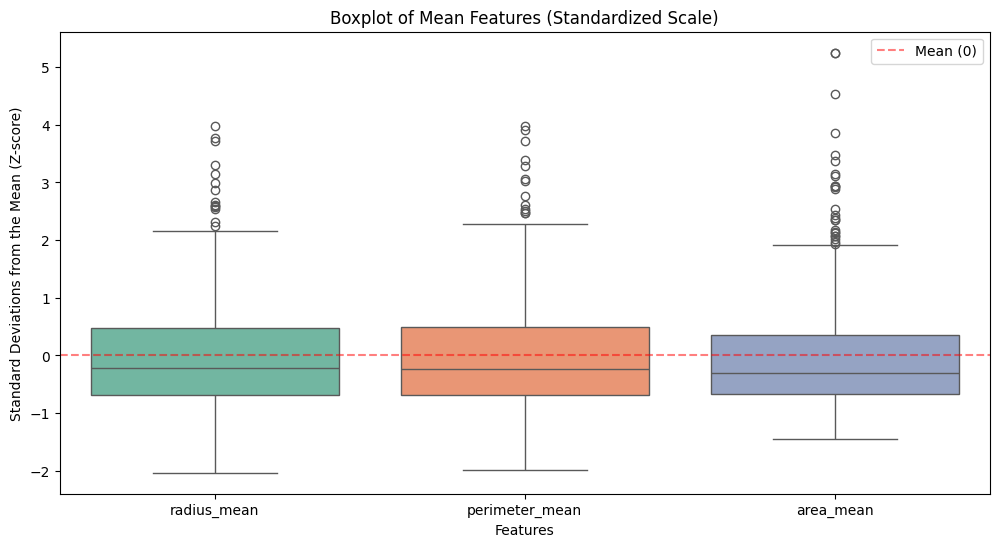

In [68]:
features_to_plot = ['radius_mean', 'perimeter_mean', 'area_mean']

# 1. Initialize the StandardScaler
scaler = StandardScaler()

# 2. Fit the scaler to the data and transform it
# This converts the raw numbers into standardized Z-scores
scaled_values = scaler.fit_transform(dataset[features_to_plot])

# 3. Convert the output (a numpy array) back into a Pandas DataFrame for easy plotting
df_scaled = pd.DataFrame(scaled_values, columns=features_to_plot)
# 4. Plot the standardized data
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_scaled, palette="Set2")

# Add a dashed line at 0 to represent the mean for all features
plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Mean (0)')

plt.title("Boxplot of Mean Features (Standardized Scale)")
plt.ylabel("Standard Deviations from the Mean (Z-score)")
plt.xlabel("Features")
plt.legend()
plt.show()

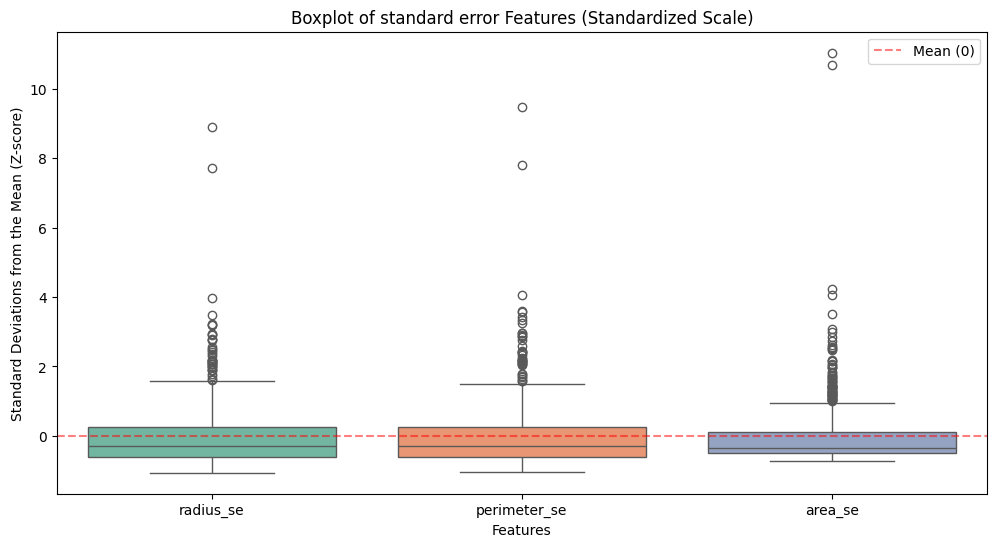

In [69]:
features_to_plot = ['radius_se', 'perimeter_se', 'area_se']

# 1. Initialize the StandardScaler
scaler = StandardScaler()

# 2. Fit the scaler to the data and transform it
# This converts the raw numbers into standardized Z-scores
scaled_values = scaler.fit_transform(dataset[features_to_plot])

# 3. Convert the output (a numpy array) back into a Pandas DataFrame for easy plotting
df_scaled = pd.DataFrame(scaled_values, columns=features_to_plot)
# 4. Plot the standardized data
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_scaled, palette="Set2")

# Add a dashed line at 0 to represent the mean for all features
plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Mean (0)')

plt.title("Boxplot of standard error Features (Standardized Scale)")
plt.ylabel("Standard Deviations from the Mean (Z-score)")
plt.xlabel("Features")
plt.legend()
plt.show()

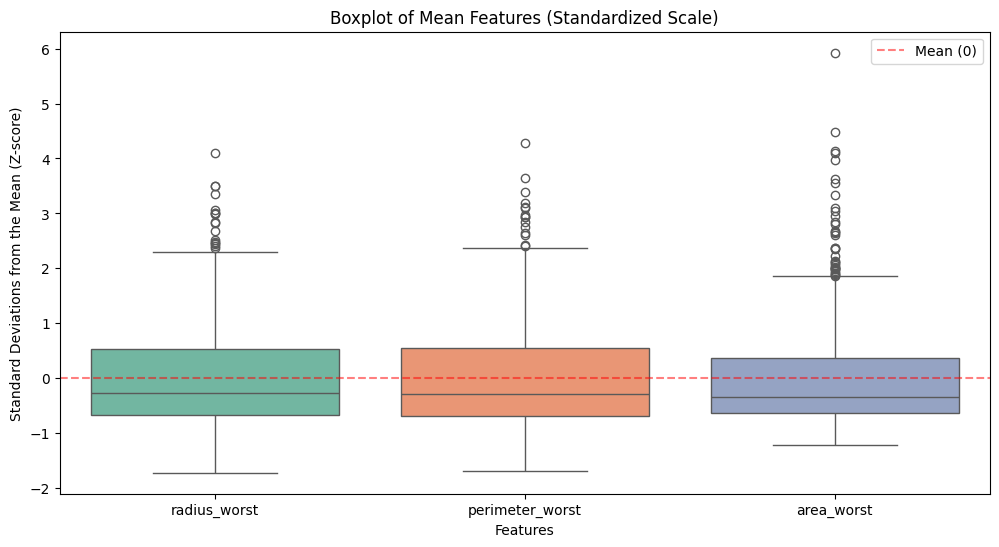

In [70]:
features_to_plot = ['radius_worst', 'perimeter_worst', 'area_worst']

# 1. Initialize the StandardScaler
scaler = StandardScaler()

# 2. Fit the scaler to the data and transform it
# This converts the raw numbers into standardized Z-scores
scaled_values = scaler.fit_transform(dataset[features_to_plot])

# 3. Convert the output (a numpy array) back into a Pandas DataFrame for easy plotting
df_scaled = pd.DataFrame(scaled_values, columns=features_to_plot)
# 4. Plot the standardized data
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_scaled, palette="Set2")

# Add a dashed line at 0 to represent the mean for all features
plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Mean (0)')

plt.title("Boxplot of Mean Features (Standardized Scale)")
plt.ylabel("Standard Deviations from the Mean (Z-score)")
plt.xlabel("Features")
plt.legend()
plt.show()

### Feature Engineering

**Estimated volume:** Estimates the volume of the tumor based on the mean of the radius

**Formula:** $V = \frac{4}{3}\pi r^3$

**Circularity:** According to [healthline.com](https://www.healthline.com/health/benign#vs-malignant) benign tumors are smoother, clear defined edges. For a perfect circle this feature would be 1. It represents how smooth the tumor is. The area and the perimeter is used to calculate this feature.

**Formula:** $Circularity = \frac{4\pi A}{P^2}$


In [71]:
def preprocess_data(X_data, handle_outliers=False, add_features=False,
                    outlier_suffixes=['mean'], feature_suffixes=['mean'],
                    imputer_strategy='median'):
    """
    Applies dynamically selected outlier handling and feature aggregation.
    """
    df = X_data.copy()

    if handle_outliers:
        features_to_clean = []
        for suffix in outlier_suffixes:
            features_to_clean.extend([f'area_{suffix}', f'radius_{suffix}', f'perimeter_{suffix}'])

        if features_to_clean:
            lof = LocalOutlierFactor(n_neighbors=20, contamination=0.04)
            outlier_flags = lof.fit_predict(df[features_to_clean])

            # Replace outliers with NaN
            df.loc[outlier_flags == -1, features_to_clean] = np.nan

            # --- DYNAMIC IMPUTER SELECTION ---
            if imputer_strategy == 'median':
                imputer = SimpleImputer(strategy='median')
            elif imputer_strategy == 'mean':
                imputer = SimpleImputer(strategy='mean')
            elif imputer_strategy == 'knn':
                # Looks at the 5 most similar patients to guess the missing value
                imputer = KNNImputer(n_neighbors=5)
            elif imputer_strategy == 'iterative':
                # Uses regression to predict the missing value based on other columns
                imputer = IterativeImputer(random_state=42)
            else:
                raise ValueError("Invalid imputer_strategy")

            # Fit and transform
            df[features_to_clean] = imputer.fit_transform(df[features_to_clean])

    if add_features:
        # (Your existing feature aggregation logic here...)
        for suffix in feature_suffixes:
            df[f'estimated_volume_{suffix}'] = (4/3) * np.pi * (df[f'radius_{suffix}'] ** 3)
            df[f'circularity_{suffix}'] = (4 * np.pi * df[f'area_{suffix}']) / (df[f'perimeter_{suffix}'] ** 2)

    return df

In [72]:
print("--- d. System Configurations (4-Fold CV) ---\n")

# Baseline: Raw data
baseline_model = DecisionTreeClassifier(random_state=42)
cv_results_base = cross_validate(baseline_model, X_train_val, y_train_val, cv=4, scoring=['f1', 'accuracy'])
print(f"Baseline F1-Score: {cv_results_base['test_f1'].mean():.4f}")
print(f"Baseline Accuracy: {cv_results_base['test_accuracy'].mean():.4f}\n")

# Config 2: Feature Aggregation Only (No Outlier Removal = No Imputation)
X_c2 = preprocess_data(X_train_val, handle_outliers=False, add_features=True)
model_c2 = DecisionTreeClassifier(random_state=42)
res_c2 = cross_validate(model_c2, X_c2, y_train_val, cv=4, scoring=['f1', 'accuracy'])
print(f"Config 2 (Features Added - Mean Only) F1:         {res_c2['test_f1'].mean():.4f}")
print(f"Config 2 (Features Added - Mean Only) Accuracy:   {res_c2['test_accuracy'].mean():.4f}\n")

strategies_to_test = ['mean', 'median', 'knn', 'iterative']

for strategy in strategies_to_test:
    print(f"==================================================")
    print(f"  TESTING IMPUTER STRATEGY: {strategy.upper()}")
    print(f"==================================================")

    # --- Config 1: Outliers Removed (Mean Only) ---
    X_c1 = preprocess_data(
        X_train_val,
        handle_outliers=True,
        add_features=False,
        imputer_strategy=strategy
    )
    model_c1 = DecisionTreeClassifier(random_state=42)
    res_c1 = cross_validate(model_c1, X_c1, y_train_val, cv=4, scoring=['f1', 'accuracy'])
    print(f"Config 1 (Outliers Removed) F1:       {res_c1['test_f1'].mean():.4f}")
    print(f"Config 1 (Outliers Removed) Accuracy: {res_c1['test_accuracy'].mean():.4f}\n")


    # --- Config 3: Outliers + Features (ALL Suffixes) ---
    X_c3 = preprocess_data(
        X_train_val,
        handle_outliers=True,
        add_features=True,
        outlier_suffixes=['mean', 'se', 'worst'],
        feature_suffixes=['mean', 'se', 'worst'],
        imputer_strategy=strategy
    )
    model_c3 = DecisionTreeClassifier(random_state=42)
    res_c3 = cross_validate(model_c3, X_c3, y_train_val, cv=4, scoring=['f1', 'accuracy'])
    print(f"Config 3 (All Suffixes) F1:           {res_c3['test_f1'].mean():.4f}")
    print(f"Config 3 (All Suffixes) Accuracy:     {res_c3['test_accuracy'].mean():.4f}\n")




--- d. System Configurations (4-Fold CV) ---

Baseline F1-Score: 0.9012
Baseline Accuracy: 0.9274

Config 2 (Features Added - Mean Only) F1:         0.8826
Config 2 (Features Added - Mean Only) Accuracy:   0.9120

  TESTING IMPUTER STRATEGY: MEAN
Config 1 (Outliers Removed) F1:       0.9012
Config 1 (Outliers Removed) Accuracy: 0.9274

Config 3 (All Suffixes) F1:           0.9068
Config 3 (All Suffixes) Accuracy:     0.9295

  TESTING IMPUTER STRATEGY: MEDIAN
Config 1 (Outliers Removed) F1:       0.9012
Config 1 (Outliers Removed) Accuracy: 0.9274

Config 3 (All Suffixes) F1:           0.8773
Config 3 (All Suffixes) Accuracy:     0.9075

  TESTING IMPUTER STRATEGY: KNN
Config 1 (Outliers Removed) F1:       0.9012
Config 1 (Outliers Removed) Accuracy: 0.9274

Config 3 (All Suffixes) F1:           0.9068
Config 3 (All Suffixes) Accuracy:     0.9295

  TESTING IMPUTER STRATEGY: ITERATIVE
Config 1 (Outliers Removed) F1:       0.9012
Config 1 (Outliers Removed) Accuracy: 0.9274

Config 3 (A

### Final Evaluation

In [73]:
print("--- e. Final Evaluation (Test Set) using Config 3 + Iterative Imputation ---")

final_model = DecisionTreeClassifier(random_state=42)


X_train_val_final = preprocess_data(
    X_train_val,
    handle_outliers=True,
    add_features=True,
    outlier_suffixes=['mean', 'se', 'worst'],
    feature_suffixes=['mean', 'se', 'worst'],
    imputer_strategy='iterative'
)

final_model.fit(X_train_val_final, y_train_val)

X_test_final = preprocess_data(
    X_test,
    handle_outliers=True,
    add_features=True,
    outlier_suffixes=['mean', 'se', 'worst'],
    feature_suffixes=['mean', 'se', 'worst'],
    imputer_strategy='iterative'
)

test_predictions = final_model.predict(X_test_final)

final_f1 = f1_score(y_test, test_predictions)
final_acc = accuracy_score(y_test, test_predictions)

print("Simulating future test at client site...\n")
print(f"Final Test F1-Score: {final_f1:.4f}")
print(f"Final Test Accuracy: {final_acc:.4f}\n")

print("--- Detailed Classification Report ---")
print(classification_report(y_test, test_predictions, target_names=['Benign (0)', 'Malignant (1)']))

print("--- Confusion Matrix ---")
# Format:
# [True Negatives,  False Positives]
# [False Negatives, True Positives ]
print(confusion_matrix(y_test, test_predictions))

--- e. Final Evaluation (Test Set) using Config 3 + Iterative Imputation ---
Simulating future test at client site...

Final Test F1-Score: 0.9512
Final Test Accuracy: 0.9649

--- Detailed Classification Report ---
               precision    recall  f1-score   support

   Benign (0)       0.96      0.99      0.97        72
Malignant (1)       0.97      0.93      0.95        42

     accuracy                           0.96       114
    macro avg       0.97      0.96      0.96       114
 weighted avg       0.97      0.96      0.96       114

--- Confusion Matrix ---
[[71  1]
 [ 3 39]]



# Empirical Study: Results Analysis

## Analysis of Obtained Results and Improvements

The cross-validation experiments reveal nuanced interactions between data preprocessing and model performance.

* **Baseline vs. Config 1 (Outlier Removal Only):** Both the Baseline and Config 1 achieved the exact same F1-Score ($0.9012$) and Accuracy ($0.9274$). This indicates that removing outliers from *only* the 'mean' geometric features did not sufficiently alter the data distribution to change the Decision Tree's splitting logic.
* **Baseline vs. Config 2 (Feature Aggregation Only):** Simply adding the engineered features (`estimated_volume` and `circularity`) without cleaning the data first degraded performance, dropping the F1-Score to $0.8826$.
* **Config 3 (All Suffixes) across Imputers:** This configuration demonstrated the most variance. When paired with **Median** imputation, performance plummeted to an F1 of $0.8773$. However, when paired with **Mean**, **KNN**, or **Iterative** imputation, Config 3 achieved the highest cross-validation F1-Score of $0.9068$ and an Accuracy of $0.9295$.

**Conclusion on Improvements:** Improvement was only achieved when *both* extensive outlier removal (across mean, se, and worst) and feature aggregation were combined with an appropriate imputation strategy (like Iterative or KNN).

## The Impact of Outlier Detection and Feature Aggregation


* **Synergy of Features and Reconstruction:** Feature aggregation (calculating volume and circularity) only succeeded when the underlying data was properly reconstructed. `IterativeImputer` uses regression to rebuild missing values based on the other healthy features. Because radius, area, and perimeter are mathematically linked, Iterative imputation rebuilt the removed outliers with high fidelity. Once the data was cleanly reconstructed, the Decision Tree was finally able to leverage the engineered Volume and Circularity features to find better decision boundaries, yielding the improved $0.9068$ score.

## Unseen Test Set vs. Cross-Validation Results

The transition to the unseen Test Set using the winning configuration (Config 3 + Iterative Imputation) yielded strong results that vastly outperformed the cross-validation estimates.

* **Performance Leap:** The final Test F1-Score jumped to **$0.9512$** (up from CV $0.9068$) and Test Accuracy reached **$0.9649$** (up from CV $0.9295$).
* **Confusion Matrix Breakdown:** Out of 114 unseen patients, the model made only 4 total errors. It achieved a staggering **99% Recall for Benign tumors** (catching 71 out of 72) and a **93% Recall for Malignant tumors** (catching 39 out of 42).
